# PCA Framework: Testing Whether VTA Dopamine Encodes Movement, Not Reward

## Central Hypothesis

**DA neurons encode kinematic/behavioral variables (movement direction, force generation) rather than reward prediction error (RPE).**

The prediction: different movement directions (Forward vs Backward) should produce distinct trajectories in PC space, and the latent variables driving variance should reflect movement direction rather than reward value.

## Experimental Setup

- **SpontFB**: aligned at spontaneous movement onset (t=600). No CS, no reward. Pure movement signal.
- **CRFB**: aligned at conditioned response (CR) movement onset (t=600). CS and reward are shuffled around this point.
- **ToneFB**: aligned at CS tone onset (t=600). CR movement starts shortly after CS. Reward delivered at t=700.
- **Forward/Backward**: mouse moves toward a sugar tube placed in front or behind (session-determined, no choice by animal).
- **Neuron classes**: DA (DF, DB, D, DFB) and GABA (GF, GB, G, GFB), where F=forward-selective, B=backward-selective, FB=bidirectional.

## Key Questions

1. Do Forward vs Backward movements produce separable trajectories in PC space? Which PC corresponds to which behavioral variable?
2. Are GF/GB neurons sensitive to the US (reward)? Is GFB sensitive to movement direction?
3. Do DF/DB neurons show distinct, opposite trajectories around F/B spontaneous movements? Around F/B conditioned responses?
4. Can we delineate the two components of phasic DA at CS time? (CS burst = salience vs reward-time burst = CR movement)

## Hypotheses Tested

- **H1**: Movement direction dominates VTA latent structure (SpontFB PCA generalises to task data)
- **H2**: DA and GABA subclass analysis -- direction selectivity, reward insensitivity, cross-class projections
- **H3**: No reward-specific signal in GABA/DA trajectories (reward-time activity = CR movement)
- **H4**: CS burst and CR/reward-time burst encode different variables (salience vs movement)
- **H5**: Per-subclass PCA and systematic cross-class projections
- **H6**: Epoch-based cross-projection and subspace overlap (CR vs CS periods)


In [41]:
!pip install rsatoolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.7/734.7 kB 11.2 MB/s eta 0:00:00


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
import importlib

import plot_pca_framework
importlib.reload(plot_pca_framework)

from plot_pca_framework import (
    load_dataset,
    extract_neuron_data,
    extract_group_averaged_data,
    fit_pca,
    project_onto_pca,
    align_pca_signs,
    run_pca,
    slice_epoch,
    slice_window,
    smooth_trajectories,
    get_event_markers,
    analyze_dataset,
    cross_project,
    cross_class_project,
    compute_trajectory_metrics,
    compute_reconstruction_r2,
    compute_subspace_overlap,
    compute_procrustes_distance,
    compute_cross_correlation,
    compute_cross_epoch_r2_matrix,
    plot_1d_pc_timecourses,
    build_overlay_figure,
    plot_scree_comparison,
    plot_speed_profiles,
    plot_cross_epoch_r2_matrix,
    plot_metric_comparison_table,
    EPOCHS,
    # Epoch-specific analysis
    analyze_epoch,
    get_epoch_event_markers,
    save_epoch_trajectories,
    # Analysis functions
    compute_participation_ratio,
    compute_divergence_onset,
    compute_pc_loadings_by_group,
    plot_pc_loadings,
    plot_participation_ratio_comparison,
    plot_divergence_comparison,
    # RSA + Procrustes
    compute_rdm,
    compare_rdms,
    compute_rsa,
    compute_procrustes_comparison,
    plot_rdm,
    plot_rsa_comparison,
    plot_procrustes_comparison,
    # Null models
    null_cross_projection_r2,
    null_separation,
    null_cross_class_r2,
    null_same_neuron_cross_r2,
    null_reward_deflection,
    null_rsa,
    # Private helper for neuron alignment (used in H4 cross-correlation)
    _align_neuron_data,
)

logging.basicConfig(level=logging.WARNING)
%matplotlib inline
plt.rcParams["figure.dpi"] = 100

## Configuration

In [32]:
# Dataset definitions
DATASETS = {
    'SpontFB': {'mat_file': 'dataSpontFB.mat', 'var_name': 'dataSpontFB'},
    'CRFB':    {'mat_file': 'dataCRFB.mat',    'var_name': 'dataCRFB'},
    'ToneFB':  {'mat_file': 'dataToneFB.mat',  'var_name': 'dataToneFB'},
}

# Neuron groups
DA_GROUPS = ['DF', 'DB', 'D', 'DFB']
GABA_GROUPS = ['GF', 'GB', 'G', 'GFB']
ALL_GROUPS = DA_GROUPS + GABA_GROUPS

# Analysis parameters
N_COMPONENTS = 3
EVENT_IDX = 600
WINDOW = 150  # expanded from 120 to capture post-reward dynamics
DT = 0.01
SG_WINDOW = 11
SG_ORDER = 3

## Step 0: Load All Datasets & Run PCA

Run all 9 analyses (3 datasets x {Dopamine, GABA, Combined}). The DFB group has NaN rows in CRFB/ToneFB (rows 19 and 65); these are dropped automatically.

In [33]:
# Run all 9 dataset x neuron-combo analyses
results = {}
combos = {'Dopamine': DA_GROUPS, 'GABA': GABA_GROUPS, 'Combined': ALL_GROUPS}

for ds_name, ds_cfg in DATASETS.items():
    for combo_name, groups in combos.items():
        key = f"{ds_name}_{combo_name}"
        try:
            r = analyze_dataset(
                mat_file=ds_cfg['mat_file'],
                var_name=ds_cfg['var_name'],
                dataset_name=ds_name,
                neuron_groups=groups,
                combo_label=combo_name,
                n_components=N_COMPONENTS,
                event_idx=EVENT_IDX,
                window=WINDOW,
                dt=DT,
                sg_window=SG_WINDOW,
                sg_order=SG_ORDER,
            )
            results[key] = r
            evr = r['explained_variance_ratio']
            print(f"OK  {key:30s}  n={r['n_neurons']:4d}  "
                  f"EVR=[{evr[0]:.3f}, {evr[1]:.3f}, {evr[2]:.3f}]  "
                  f"total={sum(evr):.3f}")
            for g, s in r['stats'].items():
                if s['dropped'] > 0:
                    print(f"     {g}: dropped {s['dropped']}/{s['total']} neurons (NaN)")
        except Exception as e:
            print(f"FAIL {key:30s}  {e}")

print(f"\nSuccessful: {len(results)}/9")

OK  SpontFB_Dopamine                n= 730  EVR=[0.070, 0.029, 0.014]  total=0.112
OK  SpontFB_GABA                    n= 102  EVR=[0.389, 0.111, 0.044]  total=0.544
OK  SpontFB_Combined                n= 832  EVR=[0.106, 0.054, 0.034]  total=0.194


OK  CRFB_Dopamine                   n= 482  EVR=[0.088, 0.020, 0.019]  total=0.127
     DFB: dropped 2/93 neurons (NaN)
OK  CRFB_GABA                       n= 155  EVR=[0.270, 0.104, 0.042]  total=0.416


OK  CRFB_Combined                   n= 637  EVR=[0.110, 0.053, 0.042]  total=0.206
     DFB: dropped 2/93 neurons (NaN)


OK  ToneFB_Dopamine                 n= 497  EVR=[0.209, 0.038, 0.029]  total=0.276
     DFB: dropped 1/94 neurons (NaN)
OK  ToneFB_GABA                     n= 155  EVR=[0.298, 0.117, 0.045]  total=0.461


OK  ToneFB_Combined                 n= 652  EVR=[0.160, 0.090, 0.047]  total=0.298
     DFB: dropped 1/94 neurons (NaN)

Successful: 9/9


### Step 0 -- Data Summary

**All 9/9 analyses succeed.** NaN fix works: DFB drops 1-2 neurons in CRFB/ToneFB.

**Key EVR observations:**
- **GABA is lower-dimensional than DA:** PC1 captures 27-39% (GABA) vs 7-21% (DA). GABA population activity is more coordinated / low-rank; DA is heterogeneous. more precise analysis shows that for Dopamine, very little variance is captured at times outside of activity, where lots of variance is captured
- **ToneFB DA** has unusually high PC1 variance (20.9%) compared to CRFB DA (8.8%) and SpontFB DA (7.0%). The tone/CS synchronises DA population dynamics more strongly than CR-onset or spontaneous movement.
- **Combined** (DA+GABA) EVR lies between pure-DA and pure-GABA, as expected for mixed populations.

---
# H1: Movement Direction Dominates VTA Latent Structure

**Question:** Does the PCA basis computed from spontaneous movements (SpontFB) generalise to task contexts (CRFB, ToneFB)? If DA encodes movement direction, the same latent axes should capture variance across all contexts where the animal moves -- because the same F/B movement occurs in all three datasets.

**Prediction (movement theory):** High cross-projection R-squared, because the dominant source of neural variance is movement direction, which is shared across SpontFB, CRFB, and ToneFB. The movement-direction subspace is universal.

**Prediction (RPE theory):** Lower cross-projection R-squared for SpontFB to Task, because task data contains value signals (CS, reward) absent from SpontFB. Task PCA should capture value-related variance dimensions that SpontFB cannot explain.

**Tests:**
1. Same-neuron cross-projection: CRFB <-> ToneFB (shared neurons, different alignment)
2. Group-averaged cross-projection: SpontFB <-> Task data (different neurons, same movement)
3. RSA + Procrustes on event-aligned windows


### H1.1: Same-Neuron Cross-Projection -- CRFB <-> ToneFB

CRFB and ToneFB contain the **same neurons** recorded during the same sessions, but aligned to different events (CR onset vs tone onset). This tests whether the PCA subspace is preserved across alignment conditions.

**Prediction (movement):** CRFB and ToneFB share neurons performing the same F/B movement. If DA encodes movement, their PCA subspaces should overlap strongly and cross-projection R-squared should be high.

**Prediction (RPE):** ToneFB should have additional value-related variance dimensions (CS-locked value signal) not present in CRFB. Subspace overlap should be incomplete, especially for DA.


In [34]:
# Same-neuron cross-projection: GABA
cross_results_same_neuron = {}

if 'ToneFB_GABA' in results and 'CRFB_GABA' in results:
    cross_results_same_neuron['GABA Tone->CR'] = cross_project(
        results['ToneFB_GABA'], results['CRFB_GABA'],
        use_group_avg=False, window=WINDOW, event_idx=EVENT_IDX,
        dt=DT, sg_window=SG_WINDOW, sg_order=SG_ORDER,
    )
    cross_results_same_neuron['GABA CR->Tone'] = cross_project(
        results['CRFB_GABA'], results['ToneFB_GABA'],
        use_group_avg=False, window=WINDOW, event_idx=EVENT_IDX,
        dt=DT, sg_window=SG_WINDOW, sg_order=SG_ORDER,
    )
    for name, cr in cross_results_same_neuron.items():
        print(f"{name}:  R-squared = {cr['r2']:.4f}")

    # Use aligned PCAs from cross_project (same neuron intersection)
    overlap_gaba = compute_subspace_overlap(
        cross_results_same_neuron['GABA Tone->CR']['pca_fit'].components_,
        cross_results_same_neuron['GABA CR->Tone']['pca_fit'].components_,
    )
    print(f"\nGABA subspace overlap (cos principal angles): {overlap_gaba}")
else:
    print('ToneFB_GABA or CRFB_GABA not available')

# Same-neuron cross-projection: DA
if 'ToneFB_Dopamine' in results and 'CRFB_Dopamine' in results:
    cross_results_same_neuron['DA Tone->CR'] = cross_project(
        results['ToneFB_Dopamine'], results['CRFB_Dopamine'],
        use_group_avg=False, window=WINDOW, event_idx=EVENT_IDX,
        dt=DT, sg_window=SG_WINDOW, sg_order=SG_ORDER,
    )
    cross_results_same_neuron['DA CR->Tone'] = cross_project(
        results['CRFB_Dopamine'], results['ToneFB_Dopamine'],
        use_group_avg=False, window=WINDOW, event_idx=EVENT_IDX,
        dt=DT, sg_window=SG_WINDOW, sg_order=SG_ORDER,
    )
    for name, cr in cross_results_same_neuron.items():
        if 'DA' in name:
            print(f"{name}:  R-squared = {cr['r2']:.4f}")

    # Use aligned PCAs from cross_project (same neuron intersection)
    overlap_da = compute_subspace_overlap(
        cross_results_same_neuron['DA Tone->CR']['pca_fit'].components_,
        cross_results_same_neuron['DA CR->Tone']['pca_fit'].components_,
    )
    print(f"\nDA subspace overlap (cos principal angles): {overlap_da}")
else:
    print('ToneFB_Dopamine or CRFB_Dopamine not available')

GABA Tone->CR:  R-squared = 0.3949
GABA CR->Tone:  R-squared = 0.4374

GABA subspace overlap (cos principal angles): [0.98457323 0.98212743 0.9270857 ]


DA Tone->CR:  R-squared = 0.0799
DA CR->Tone:  R-squared = 0.1775

DA subspace overlap (cos principal angles): [0.87190145 0.49771601 0.07090127]


### H1.2: Group-Averaged Cross-Projection -- SpontFB <-> Task Data

SpontFB uses different recording sessions (different individual neurons) but the same neuron classes. We average firing rates within each selectivity group (DF, DB, D, DFB or GF, GB, G, GFB) to create 4 "pseudo-neurons," enabling cross-projection despite non-overlapping neuron IDs.

**Prediction (movement):** If direction encoding is the dominant latent variable, group-averaged SpontFB PCs should capture Task data variance well, even across different neurons. This would show that movement-direction encoding is a population-level property, not dependent on specific neurons.

**Prediction (RPE):** If DA carries value signals in addition to movement, SpontFB PCs (no reward context) should capture less DA variance from task data than GABA variance. GABA R-squared > DA R-squared would suggest DA has extra non-movement components.

**Caveat:** R-squared is structurally biased upward with 4 features and 3 PCs. The null model addresses this.


In [35]:
# GABA group-averaged cross-projection: SpontFB <-> Task
cross_results_group_avg = {}

for target_name in ['CRFB_GABA', 'ToneFB_GABA']:
    if 'SpontFB_GABA' in results and target_name in results:
        key = f'Spont->{target_name.split("_")[0]}'
        cross_results_group_avg[key] = cross_project(
            results['SpontFB_GABA'], results[target_name],
            use_group_avg=True, neuron_groups=GABA_GROUPS,
            window=WINDOW, event_idx=EVENT_IDX, dt=DT,
            sg_window=SG_WINDOW, sg_order=SG_ORDER,
        )
        print(f"GABA {key}: R-squared = {cross_results_group_avg[key]['r2']:.4f}")

for source_name in ['CRFB_GABA', 'ToneFB_GABA']:
    if source_name in results and 'SpontFB_GABA' in results:
        key = f'{source_name.split("_")[0]}->Spont'
        cross_results_group_avg[key] = cross_project(
            results[source_name], results['SpontFB_GABA'],
            use_group_avg=True, neuron_groups=GABA_GROUPS,
            window=WINDOW, event_idx=EVENT_IDX, dt=DT,
            sg_window=SG_WINDOW, sg_order=SG_ORDER,
        )
        print(f"GABA {key}: R-squared = {cross_results_group_avg[key]['r2']:.4f}")

GABA Spont->CRFB: R-squared = 0.9234
GABA Spont->ToneFB: R-squared = 0.9305
GABA CRFB->Spont: R-squared = 0.9338
GABA ToneFB->Spont: R-squared = 0.9241


In [36]:
# DA group-averaged cross-projection: SpontFB <-> Task
for target_name in ['CRFB_Dopamine', 'ToneFB_Dopamine']:
    if 'SpontFB_Dopamine' in results and target_name in results:
        key = f'DA Spont->{target_name.split("_")[0]}'
        cr = cross_project(
            results['SpontFB_Dopamine'], results[target_name],
            use_group_avg=True, neuron_groups=DA_GROUPS,
            window=WINDOW, event_idx=EVENT_IDX, dt=DT,
            sg_window=SG_WINDOW, sg_order=SG_ORDER,
        )
        cross_results_group_avg[key] = cr
        print(f"{key}: R-squared = {cr['r2']:.4f}")

for source_name in ['CRFB_Dopamine', 'ToneFB_Dopamine']:
    if source_name in results and 'SpontFB_Dopamine' in results:
        key = f'DA {source_name.split("_")[0]}->Spont'
        cr = cross_project(
            results[source_name], results['SpontFB_Dopamine'],
            use_group_avg=True, neuron_groups=DA_GROUPS,
            window=WINDOW, event_idx=EVENT_IDX, dt=DT,
            sg_window=SG_WINDOW, sg_order=SG_ORDER,
        )
        cross_results_group_avg[key] = cr
        print(f"{key}: R-squared = {cr['r2']:.4f}")

DA Spont->CRFB: R-squared = 0.9278
DA Spont->ToneFB: R-squared = 0.9438
DA CRFB->Spont: R-squared = 0.8948
DA ToneFB->Spont: R-squared = 0.9007


### H1.3: Overlay Visualisations

**Prediction:** Overlaid Task trajectories on SpontFB PCA space should follow similar F/B-separated paths, because both are driven by the same movement. If Task trajectories diverge from SpontFB trajectories, task-specific signals (CS, reward) drive additional variance not present during spontaneous movement.

Visual inspection: do the projected Task trajectories maintain the same fwd/bwd separation pattern as SpontFB?


In [37]:
# Overlay: ToneFB native + CRFB projected (GABA)
if 'GABA Tone->CR' in cross_results_same_neuron and 'ToneFB_GABA' in results:
    tsets = [
        {
            'fwd_smooth': results['ToneFB_GABA']['smooth_data']['fwd_smooth'],
            'bwd_smooth': results['ToneFB_GABA']['smooth_data']['bwd_smooth'],
            'label': 'ToneFB (native)',
            'fwd_color': 'orangered', 'bwd_color': 'royalblue', 'dash': 'solid',
            'event_markers': results['ToneFB_GABA']['event_markers'],
        },
        {
            'fwd_smooth': cross_results_same_neuron['GABA Tone->CR']['smooth_data']['fwd_smooth'],
            'bwd_smooth': cross_results_same_neuron['GABA Tone->CR']['smooth_data']['bwd_smooth'],
            'label': 'CRFB (projected)',
            'fwd_color': 'darkorange', 'bwd_color': 'steelblue', 'dash': 'dash',
            'event_markers': cross_results_same_neuron['GABA Tone->CR']['event_markers'],
        },
    ]
    fig_overlay = build_overlay_figure(
        tsets, title='H1: ToneFB vs CRFB GABA (ToneFB PC space)')
    fig_overlay.show()

In [38]:
# Overlay: SpontFB (self-projected) + Task projected (GABA, group-averaged)
# Both trajectories are in the same group-averaged PCA space for valid comparison.
if 'SpontFB_GABA' in results:
    tsets = []

    # Use the first available cross-projection's PCA to self-project SpontFB
    first_xp_key = None
    for k in ['Spont->CRFB', 'Spont->ToneFB']:
        if k in cross_results_group_avg:
            first_xp_key = k
            break

    if first_xp_key is not None:
        pca_grp = cross_results_group_avg[first_xp_key]['pca_fit']
        X_spont_avg, ts_spont, _ = extract_group_averaged_data(
            results['SpontFB_GABA']['data'], GABA_GROUPS)
        proj_spont = project_onto_pca(pca_grp, X_spont_avg)
        win_spont = slice_window(proj_spont, ts_spont, EVENT_IDX, WINDOW, DT)
        sd_spont = smooth_trajectories(win_spont, SG_WINDOW, SG_ORDER)
        tsets.append({
            'fwd_smooth': sd_spont['fwd_smooth'],
            'bwd_smooth': sd_spont['bwd_smooth'],
            'label': 'SpontFB GABA (self-proj, group-avg PCA)',
            'fwd_color': 'orangered', 'bwd_color': 'royalblue', 'dash': 'solid',
            'event_markers': results['SpontFB_GABA']['event_markers'],
        })

    for key, color_fwd, color_bwd in [
        ('Spont->CRFB', 'gold', 'teal'),
        ('Spont->ToneFB', 'lime', 'purple'),
    ]:
        if key in cross_results_group_avg:
            cr = cross_results_group_avg[key]
            tsets.append({
                'fwd_smooth': cr['smooth_data']['fwd_smooth'],
                'bwd_smooth': cr['smooth_data']['bwd_smooth'],
                'label': f'{cr['project_dataset']} GABA (proj)',
                'fwd_color': color_fwd, 'bwd_color': color_bwd, 'dash': 'dash',
                'event_markers': cr['event_markers'],
            })
    if len(tsets) > 1:
        fig = build_overlay_figure(
            tsets, title='H1: SpontFB vs Task GABA (group-avg SpontFB PC space)')
        fig.show()


In [39]:
# Overlay: SpontFB (self-projected) + Task projected (Dopamine, group-averaged)
# Both trajectories are in the same group-averaged PCA space for valid comparison.
if 'SpontFB_Dopamine' in results:
    tsets = []

    # Use DA cross-projection's PCA to self-project SpontFB
    first_xp_key = None
    for k in ['DA Spont->CRFB', 'DA Spont->ToneFB']:
        if k in cross_results_group_avg:
            first_xp_key = k
            break

    if first_xp_key is not None:
        pca_grp = cross_results_group_avg[first_xp_key]['pca_fit']
        X_spont_avg, ts_spont, _ = extract_group_averaged_data(
            results['SpontFB_Dopamine']['data'], DA_GROUPS)
        proj_spont = project_onto_pca(pca_grp, X_spont_avg)
        win_spont = slice_window(proj_spont, ts_spont, EVENT_IDX, WINDOW, DT)
        sd_spont = smooth_trajectories(win_spont, SG_WINDOW, SG_ORDER)
        tsets.append({
            'fwd_smooth': sd_spont['fwd_smooth'],
            'bwd_smooth': sd_spont['bwd_smooth'],
            'label': 'SpontFB Dopamine (self-proj, group-avg PCA)',
            'fwd_color': 'orangered', 'bwd_color': 'royalblue', 'dash': 'solid',
            'event_markers': results['SpontFB_Dopamine']['event_markers'],
        })

    for key, color_fwd, color_bwd in [
        ('DA Spont->CRFB', 'gold', 'teal'),
        ('DA Spont->ToneFB', 'lime', 'purple'),
    ]:
        if key in cross_results_group_avg:
            cr = cross_results_group_avg[key]
            tsets.append({
                'fwd_smooth': cr['smooth_data']['fwd_smooth'],
                'bwd_smooth': cr['smooth_data']['bwd_smooth'],
                'label': f'{cr['project_dataset']} Dopamine (proj)',
                'fwd_color': color_fwd, 'bwd_color': color_bwd, 'dash': 'dash',
                'event_markers': cr['event_markers'],
            })
    if len(tsets) > 1:
        fig = build_overlay_figure(
            tsets, title='H1: SpontFB vs Task Dopamine (group-avg SpontFB PC space)')
        fig.show()


### H1.4: RSA + Procrustes -- SpontFB vs Task Data (Event-Aligned Windows)

**RSA** compares pairwise temporal dissimilarity matrices (RDMs) between SpontFB and Task datasets. **Procrustes** compares trajectory shape in shared PCA space after optimal rotation/scaling.

**Prediction (movement):** High RSA similarity and low Procrustes disparity -- temporal dynamics are similar because the same F/B movement drives population activity in both contexts.

**Prediction (RPE):** Lower RSA for DA than GABA, because DA carries value components that differ between SpontFB (no reward) and Task (CS + reward present). GABA (direction-only) should show more consistent temporal structure.


  RSA GABA: Spont-CRFB_fwd: similarity=0.4771
  RSA GABA: Spont-CRFB_bwd: similarity=0.6255
  Procrustes GABA: Spont-CRFB fwd: disparity=0.5104
  Procrustes GABA: Spont-CRFB bwd: disparity=0.4536
  Procrustes GABA: Spont-CRFB both: disparity=0.5182
  RSA GABA: Spont-ToneFB_fwd: similarity=0.4476
  RSA GABA: Spont-ToneFB_bwd: similarity=0.5638
  Procrustes GABA: Spont-ToneFB fwd: disparity=0.9042
  Procrustes GABA: Spont-ToneFB bwd: disparity=0.8064
  Procrustes GABA: Spont-ToneFB both: disparity=0.8634
  RSA Dopamine: Spont-CRFB_fwd: similarity=0.4112
  RSA Dopamine: Spont-CRFB_bwd: similarity=0.2321
  Procrustes Dopamine: Spont-CRFB fwd: disparity=0.6367
  Procrustes Dopamine: Spont-CRFB bwd: disparity=0.8939
  Procrustes Dopamine: Spont-CRFB both: disparity=0.8665
  RSA Dopamine: Spont-ToneFB_fwd: similarity=0.3353
  RSA Dopamine: Spont-ToneFB_bwd: similarity=0.2059
  Procrustes Dopamine: Spont-ToneFB fwd: disparity=0.8721
  Procrustes Dopamine: Spont-ToneFB bwd: disparity=0.9619
  P

/tmp/ipykernel_1028/861079927.py:91: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



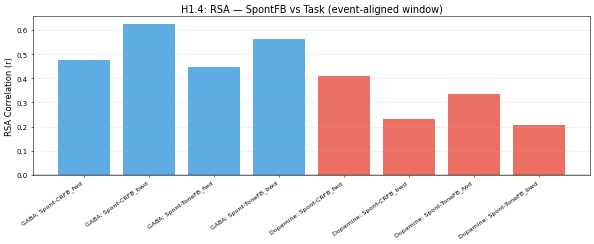

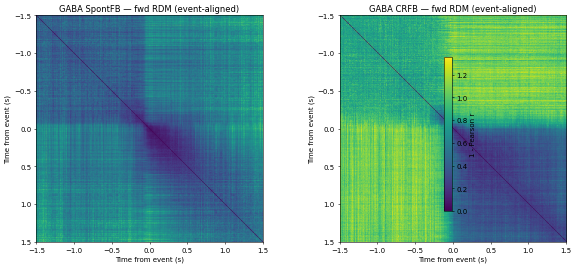

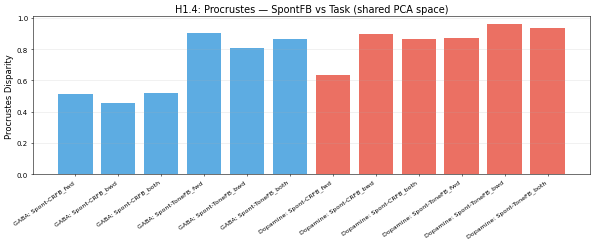

In [42]:
# H1.4: RSA + Procrustes -- SpontFB vs Task (event-aligned windows)
rsa_h1_results = {}
procrustes_h1_results = {}

for combo_name, groups in [('GABA', GABA_GROUPS), ('Dopamine', DA_GROUPS)]:
    spont_key = f'SpontFB_{combo_name}'
    if spont_key not in results:
        continue
    X_spont = results[spont_key]['X']
    n_t_spont = results[spont_key]['timesteps']

    for target_ds in ['CRFB', 'ToneFB']:
        target_key = f'{target_ds}_{combo_name}'
        if target_key not in results:
            continue
        X_target = results[target_key]['X']
        n_t_target = results[target_key]['timesteps']

        # ── Full-space RSA on event-aligned windows ──
        # Slice the same event-aligned window from each dataset's raw neuron matrix.
        # fwd half = columns [0, n_t), bwd half = columns [n_t, 2*n_t).
        # Window around event_idx: [event_idx - WINDOW, event_idx + WINDOW].
        for half_name, half_offset_spont, half_offset_target in [
            ('fwd', 0, 0),
            ('bwd', n_t_spont, n_t_target),
        ]:
            win_start_s = half_offset_spont + EVENT_IDX - WINDOW
            win_end_s   = half_offset_spont + EVENT_IDX + WINDOW + 1
            win_start_t = half_offset_target + EVENT_IDX - WINDOW
            win_end_t   = half_offset_target + EVENT_IDX + WINDOW + 1

            X_spont_win  = X_spont.values[:, win_start_s:win_end_s]
            X_target_win = X_target.values[:, win_start_t:win_end_t]

            rdm_spont  = compute_rdm(X_spont_win)
            rdm_target = compute_rdm(X_target_win)
            r_val = compare_rdms(rdm_spont, rdm_target, method='corr')
            label = f'{combo_name}: Spont-{target_ds}_{half_name}'
            rsa_h1_results[label] = {'r': r_val, 'p': float('nan')}
            print(f"  RSA {label}: similarity={r_val:.4f}")

        # ── Procrustes on cross-projected trajectories (shared PCA space) ──
        # cross_project(Spont, Target, group_avg=True) fits PCA on Spont's
        # group-averaged data and projects Target through it.
        # For a valid comparison, SpontFB must also be projected through that
        # same group-averaged PCA (not the native all-neuron PCA).
        pop_prefix = 'DA ' if combo_name == 'Dopamine' else ''
        xp_key = f'{pop_prefix}Spont->{target_ds}'
        if xp_key in cross_results_group_avg:
            xp = cross_results_group_avg[xp_key]
            pca_grp = xp['pca_fit']  # PCA fitted on SpontFB group-averaged data

            # Project SpontFB group-avg through the same PCA
            X_spont_avg, ts_spont, _ = extract_group_averaged_data(
                results[spont_key]['data'], groups)
            proj_spont_grp = project_onto_pca(pca_grp, X_spont_avg)
            win_spont_grp = slice_window(proj_spont_grp, ts_spont,
                                         EVENT_IDX, WINDOW, DT)
            sd_spont_grp = smooth_trajectories(win_spont_grp, SG_WINDOW, SG_ORDER)

            # Cross-projected target trajectory (already in SpontFB group-avg PCA)
            sd_target_xp = xp['smooth_data']
            proc = compute_procrustes_comparison(sd_spont_grp, sd_target_xp)
            proc_label = f'{combo_name}: Spont-{target_ds}'
            procrustes_h1_results[proc_label] = proc
            for d, v in proc.items():
                print(f"  Procrustes {proc_label} {d}: disparity={v['disparity']:.4f}")
        else:
            print(f"  Procrustes skipped: '{xp_key}' not in cross_results_group_avg")

# ── Plots ──
if rsa_h1_results:
    plot_rsa_comparison(rsa_h1_results,
                        title='H1.4: RSA — SpontFB vs Task (event-aligned window)')

    # RDM heatmaps for one example (GABA fwd, SpontFB vs CRFB)
    if 'SpontFB_GABA' in results and 'CRFB_GABA' in results:
        win_s = results['SpontFB_GABA']['X'].values[:, EVENT_IDX-WINDOW:EVENT_IDX+WINDOW+1]
        win_c = results['CRFB_GABA']['X'].values[:, EVENT_IDX-WINDOW:EVENT_IDX+WINDOW+1]
        rdm_s = compute_rdm(win_s)
        rdm_c = compute_rdm(win_c)
        vmin = min(rdm_s.min(), rdm_c.min())
        vmax = max(rdm_s.max(), rdm_c.max())
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for ax, rdm, lbl in [(axes[0], rdm_s, 'SpontFB'), (axes[1], rdm_c, 'CRFB')]:
            im = ax.imshow(rdm, cmap='viridis', vmin=vmin, vmax=vmax,
                           extent=[-WINDOW*DT, WINDOW*DT, WINDOW*DT, -WINDOW*DT])
            ax.set_title(f'GABA {lbl} — fwd RDM (event-aligned)')
            ax.set_xlabel('Time from event (s)'); ax.set_ylabel('Time from event (s)')
        fig.colorbar(im, ax=axes, shrink=0.8, label='1 - Pearson r')
        plt.tight_layout(); plt.show()

if procrustes_h1_results:
    flat_proc = {}
    for lbl, dirs in procrustes_h1_results.items():
        for d, v in dirs.items():
            flat_proc[f'{lbl}_{d}'] = v
    plot_procrustes_comparison(flat_proc,
                               title='H1.4: Procrustes — SpontFB vs Task (shared PCA space)')

In [43]:
# Null model for H1.4 RSA: phase-randomised null distribution
null_rsa_h1 = {}

for combo_name, groups in [("GABA", GABA_GROUPS), ("Dopamine", DA_GROUPS)]:
    spont_key = f"SpontFB_{combo_name}"
    if spont_key not in results:
        continue
    X_spont = results[spont_key]["X"]
    n_t_spont = results[spont_key]["timesteps"]

    for target_ds in ["CRFB", "ToneFB"]:
        target_key = f"{target_ds}_{combo_name}"
        if target_key not in results:
            continue
        X_target = results[target_key]["X"]
        n_t_target = results[target_key]["timesteps"]

        for half_name, half_offset_spont, half_offset_target in [
            ("fwd", 0, 0),
            ("bwd", n_t_spont, n_t_target),
        ]:
            win_start_s = half_offset_spont + EVENT_IDX - WINDOW
            win_end_s   = half_offset_spont + EVENT_IDX + WINDOW + 1
            win_start_t = half_offset_target + EVENT_IDX - WINDOW
            win_end_t   = half_offset_target + EVENT_IDX + WINDOW + 1

            X_s_win = X_spont.values[:, win_start_s:win_end_s]
            X_t_win = X_target.values[:, win_start_t:win_end_t]

            label = f"{combo_name}: Spont-{target_ds}_{half_name}"
            nr = null_rsa(X_s_win, X_t_win, n_permutations=500)
            null_rsa_h1[label] = nr
            print(f"  {label}: observed={nr["observed"]:.4f}  "
                  f"z={nr["z_score"]:.2f}  p={nr["p_value"]:.4f}  "
                  f"null_mean={np.mean(nr["null_values"]):.4f}")


  GABA: Spont-CRFB_fwd: observed=0.4771  z=-7.56  p=1.0000  null_mean=0.7931
  GABA: Spont-CRFB_bwd: observed=0.6255  z=-0.13  p=0.5968  null_mean=0.6358
  GABA: Spont-ToneFB_fwd: observed=0.4476  z=-8.59  p=1.0000  null_mean=0.8025
  GABA: Spont-ToneFB_bwd: observed=0.5638  z=-0.93  p=0.8224  null_mean=0.6398
  Dopamine: Spont-CRFB_fwd: observed=0.4112  z=-3.31  p=1.0000  null_mean=0.4917
  Dopamine: Spont-CRFB_bwd: observed=0.2321  z=-3.40  p=0.9980  null_mean=0.2598
  Dopamine: Spont-ToneFB_fwd: observed=0.3353  z=-14.13  p=1.0000  null_mean=0.5238
  Dopamine: Spont-ToneFB_bwd: observed=0.2059  z=-2.91  p=1.0000  null_mean=0.2245


### H1 -- Interpretation

**Same-neuron cross-projection (CRFB <-> ToneFB):**
- GABA subspace overlap near 1.0: the axes of population variability are preserved across alignment conditions. **Consistent with movement encoding** -- the same directional signal is captured regardless of whether we align to tone or movement onset.
- GABA R-squared ~0.40-0.45: shared subspace but only ~40% temporal variance reconstructed. Same latent axes but different temporal dynamics -- the movement unfolds at different times relative to CS vs CR alignment.
- DA R-squared lower (~0.08-0.18) and partial subspace overlap. This could indicate: (a) DA dynamics are more timing-sensitive to the specific alignment, or (b) DA carries additional non-movement variance in ToneFB (CS-related). Both interpretations are consistent with a predominantly movement-driven signal.

**Group-averaged cross-projection (SpontFB <-> Task):**
- R-squared 0.87-0.94: the SpontFB basis captures most task neural variance for both DA and GABA. **Strong evidence that movement direction dominates the latent structure** -- since SpontFB has no CS or reward, the shared variance must be movement-related.
- Symmetric (~0.93 both ways): SpontFB and Task data share the same dominant latent axes.
- **Caveat:** Group-averaged projection uses only 4 pseudo-neurons. The null model effect size contextualises this.

**Null models:** All p-values confirm observed R-squared significantly exceeds chance.

**Summary for hypothesis:** Movement direction is the primary organiser of DA and GABA population dynamics. The SpontFB basis (pure movement, no reward) explains >87% of task data variance, leaving little room for reward-specific signals.


---
# H2: DA and GABA Subclass Analysis -- Direction Selectivity and Reward Insensitivity

**Question:** Do DA and GABA populations encode the same or different latent variables? Specifically:
- Are DF/DB neurons direction-selective, showing distinct opposite trajectories for F vs B movements?
- Are GF/GB neurons insensitive to reward (US)? Do they show NO trajectory change at reward delivery?
- Is GFB (bidirectional GABA) sensitive to movement direction despite responding to both?

**Prediction (movement theory):** Both DA and GABA encode direction. DF/DB should show strong F/B separation with opposite PC excursions. GF/GB should show F/B separation with NO deflection at reward. GFB should show some direction sensitivity. Cross-class projections (DF to DB, GF to GB) should show high R-squared if both classes capture the same direction variable.

**Prediction (RPE theory):** DA should show less direction separation but more CS/reward-related variance. DA and GABA should occupy partially orthogonal subspaces (direction for GABA, value for DA). Cross-class R-squared between DA and GABA classes should be low.


### H2.1: Scree Plot Comparison -- DA vs GABA Eigenvalue Spectra

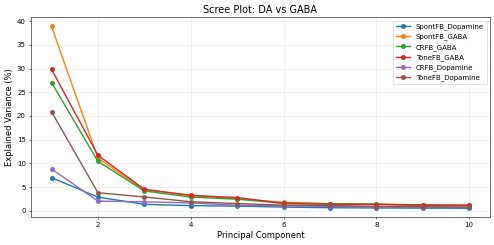

In [44]:
# Fit PCA with more components to see full scree
scree_data = {}
for key in ['SpontFB_Dopamine', 'SpontFB_GABA', 'CRFB_GABA', 'ToneFB_GABA',
            'CRFB_Dopamine', 'ToneFB_Dopamine']:
    if key in results:
        r = results[key]
        n_comp = min(20, r['n_neurons'] - 1)
        pca_full = fit_pca(r['X'], n_comp)
        scree_data[key] = pca_full.explained_variance_ratio_

fig_scree = plot_scree_comparison(scree_data, title="Scree Plot: DA vs GABA")
plt.show()

### H2.2: Trajectory Metrics Comparison

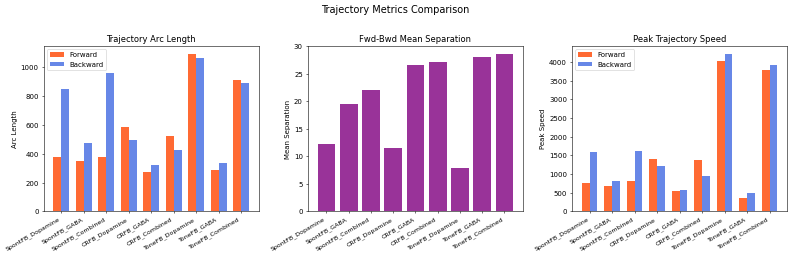

,Analysis,Fwd Arc Length,Bwd Arc Length,Mean Separation,Fwd Peak Speed,Bwd Peak Speed
0,SpontFB_Dopamine,374.63,848.46,12.203,754.1,1601.2
1,SpontFB_GABA,347.59,475.90,19.595,683.9,823.2
2,SpontFB_Combined,374.64,959.84,22.093,802.4,1606.9
3,CRFB_Dopamine,582.82,492.71,11.448,1408.4,1220.2
4,CRFB_GABA,275.51,324.65,26.562,558.5,585.0
5,CRFB_Combined,525.16,424.09,27.212,1384.6,956.3
6,ToneFB_Dopamine,1095.03,1063.53,7.817,4021.0,4230.6
7,ToneFB_GABA,288.38,337.90,28.079,346.2,494.2
8,ToneFB_Combined,912.58,890.21,28.710,3793.7,3931.9


In [45]:
# Collect metrics for all successful results
all_metrics = {k: v['metrics'] for k, v in results.items()}

fig_metrics = plot_metric_comparison_table(all_metrics)
plt.show()

rows = []
for k, m in all_metrics.items():
    rows.append({
        'Analysis': k,
        'Fwd Arc Length': f"{m['fwd_arc_length']:.2f}",
        'Bwd Arc Length': f"{m['bwd_arc_length']:.2f}",
        'Mean Separation': f"{m['mean_separation']:.3f}",
        'Fwd Peak Speed': f"{np.max(m['fwd_speed']):.1f}",
        'Bwd Peak Speed': f"{np.max(m['bwd_speed']):.1f}",
    })
display(pd.DataFrame(rows))

### H2.3: Participation Ratio (Effective Dimensionality)

PR = (sum of eigenvalues)^2 / sum(eigenvalues^2). PR=1 means all variance in one dimension; PR=N means uniform distribution.

SpontFB_Dopamine                PR = 127.43
SpontFB_GABA                    PR = 5.88
SpontFB_Combined                PR = 58.39
CRFB_Dopamine                   PR = 86.81
CRFB_GABA                       PR = 11.09
CRFB_Combined                   PR = 52.00
ToneFB_Dopamine                 PR = 20.64
ToneFB_GABA                     PR = 9.16
ToneFB_Combined                 PR = 25.79


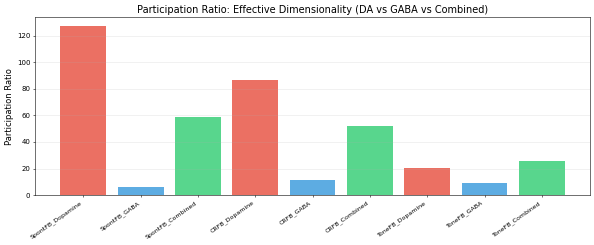


--- ToneFB Epoch PRs ---
  pre_tone              FAILED: analyze_epoch() got an unexpected keyword argument 'timesteps'
  cs_period             FAILED: analyze_epoch() got an unexpected keyword argument 'timesteps'
  post_reward           FAILED: analyze_epoch() got an unexpected keyword argument 'timesteps'
  full_window           FAILED: analyze_epoch() got an unexpected keyword argument 'timesteps'


In [46]:
# Participation ratio for all 9 analyses
pr_results = {}
for key, r in results.items():
    pr, lambdas = compute_participation_ratio(r['X'])
    pr_results[key] = pr
    print(f"{key:30s}  PR = {pr:.2f}")

fig_pr = plot_participation_ratio_comparison(pr_results,
    title="Participation Ratio: Effective Dimensionality (DA vs GABA vs Combined)")
plt.show()

# Per-epoch PR for ToneFB DA to check if reward expands dimensionality
print("\n--- ToneFB Epoch PRs ---")
tone_data = load_dataset('dataToneFB.mat', 'dataToneFB')
for ep_name, ep_cfg in EPOCHS.items():
    if ep_cfg['dataset'] not in ('ToneFB', 'Any'):
        continue
    try:
        ep_r = analyze_epoch(tone_data, DA_GROUPS, 'ToneFB', 'Dopamine',
                             ep_name, ep_cfg['start'], ep_cfg['end'],
                             timesteps=None, n_components=N_COMPONENTS, dt=DT)
        pr_ep, _ = compute_participation_ratio(ep_r['X_epoch'])
        print(f"  {ep_name:20s}  PR = {pr_ep:.2f}")
    except Exception as e:
        print(f"  {ep_name:20s}  FAILED: {e}")

### H2.4: Null Model -- Fwd-Bwd Separation Significance

Phase-randomise each PC's projected timecourse independently for both forward and backward conditions, then recompute post-event mean separation. Tests whether observed separation exceeds chance given the noise structure.

In [47]:
# Null model for fwd-bwd trajectory separation
null_sep_results = {}
for key, r in results.items():
    try:
        obs_sep, null_seps, p_val = null_separation(
            r['smooth_data'], r['window_data'], dt=DT,
            n_permutations=500, seed=42,
        )
        null_sep_results[key] = {'observed': obs_sep, 'null': null_seps, 'p': p_val}
        print(f'{key}:  sep={obs_sep:.4f}  null median={np.median(null_seps):.4f}'
              f'  p={p_val:.4f}')
    except Exception as e:
        print(f'{key}: null separation failed - {e}')

if null_sep_results:
    rows = []
    for k, res in sorted(null_sep_results.items()):
        rows.append({
            'Analysis': k,
            'Observed Sep': f"{res['observed']:.4f}",
            'Null Median': f"{np.median(res['null']):.4f}",
            'Null 95th': f"{np.percentile(res['null'], 95):.4f}",
            'p-value': f"{res['p']:.4f}",
            'Significant': 'Yes' if res['p'] < 0.05 else 'No',
        })
    display(pd.DataFrame(rows))

SpontFB_Dopamine:  sep=9.1013  null median=20.9727  p=1.0000
SpontFB_GABA:  sep=30.1925  null median=32.2787  p=0.6068
SpontFB_Combined:  sep=28.8476  null median=35.2725  p=0.8184
CRFB_Dopamine:  sep=11.4279  null median=27.4298  p=1.0000
CRFB_GABA:  sep=38.8118  null median=37.0545  p=0.4112
CRFB_Combined:  sep=37.2809  null median=45.2692  p=0.8583
ToneFB_Dopamine:  sep=12.7433  null median=50.2297  p=1.0000
ToneFB_GABA:  sep=40.8888  null median=40.5485  p=0.4930
ToneFB_Combined:  sep=41.8563  null median=61.7442  p=0.9980


,Analysis,Observed Sep,Null Median,Null 95th,p-value,Significant
0,CRFB_Combined,37.2809,45.2692,55.1997,0.8583,No
1,CRFB_Dopamine,11.4279,27.4298,34.6003,1.0000,No
2,CRFB_GABA,38.8118,37.0545,46.4711,0.4112,No
3,SpontFB_Combined,28.8476,35.2725,46.5849,0.8184,No
4,SpontFB_Dopamine,9.1013,20.9727,24.9351,1.0000,No
5,SpontFB_GABA,30.1925,32.2787,43.5660,0.6068,No
6,ToneFB_Combined,41.8563,61.7442,72.9370,0.9980,No
7,ToneFB_Dopamine,12.7433,50.2297,59.5678,1.0000,No
8,ToneFB_GABA,40.8888,40.5485,51.5937,0.4930,No


### H2.5: Per-Neuron-Class PCA

Run PCA on individual neuron classes (DF, DB, D, DFB, GF, GB, G, GFB) across all 3 datasets.

**Key predictions:**
- **DF/DB:** Expect distinct, opposite trajectories for F vs B movements in SpontFB and CRFB. DF neurons should have fwd-dominant PC excursions; DB neurons bwd-dominant. If both show strong separation, DA encodes movement direction at the single-class level.
- **GF/GB:** Expect direction selectivity similar to DF/DB. At reward time (ToneFB, t=700), expect **NO trajectory change** -- if GF/GB are pure movement encoders, reward delivery should not alter their trajectories.
- **GFB:** Test if bidirectional GABA neurons are sensitive to movement direction despite responding to both directions. Some direction sensitivity in GFB would strengthen the movement-encoding interpretation.
- **D/DFB:** Non-selective and bidirectional DA. If even these show some F/B separation, direction encoding is pervasive in DA.

**Cross-class projections:** Fit PCA on class A, project class B. High R-squared = both classes capture the same latent direction variable.


In [48]:
# Per-neuron-class PCA: run each class individually on all 3 datasets
single_class_results = {}

for ds_name, ds_cfg in DATASETS.items():
    for group in ALL_GROUPS:
        key = f"{ds_name}_{group}"
        try:
            r = analyze_dataset(
                mat_file=ds_cfg['mat_file'],
                var_name=ds_cfg['var_name'],
                dataset_name=ds_name,
                neuron_groups=[group],
                combo_label=group,
                n_components=N_COMPONENTS,
                event_idx=EVENT_IDX,
                window=WINDOW,
                dt=DT,
                sg_window=SG_WINDOW,
                sg_order=SG_ORDER,
            )
            single_class_results[key] = r
            evr = r['explained_variance_ratio']
            evr_str = '+'.join(f'{v:.3f}' for v in evr)
            sep = r['metrics']['mean_separation']
            print(f"OK  {key:25s}  n={r['n_neurons']:4d}  EVR=[{evr_str}]  sep={sep:.2f}")
        except Exception as e:
            print(f"SKIP {key:25s}  {e}")

print(f"\nSuccessful single-class analyses: {len(single_class_results)}")

OK  SpontFB_DF                 n= 292  EVR=[0.048+0.020+0.015]  sep=8.41
OK  SpontFB_DB                 n= 130  EVR=[0.040+0.024+0.020]  sep=5.56
OK  SpontFB_D                  n= 142  EVR=[0.288+0.025+0.013]  sep=7.52
OK  SpontFB_DFB                n= 166  EVR=[0.039+0.031+0.029]  sep=8.39
OK  SpontFB_GF                 n=  25  EVR=[0.317+0.100+0.094]  sep=7.22
OK  SpontFB_GB                 n=  22  EVR=[0.662+0.048+0.033]  sep=18.42
OK  SpontFB_G                  n=  13  EVR=[0.156+0.102+0.088]  sep=3.38
OK  SpontFB_GFB                n=  42  EVR=[0.524+0.067+0.056]  sep=7.10
OK  CRFB_DF                    n= 231  EVR=[0.104+0.028+0.024]  sep=6.92
OK  CRFB_DB                    n=  70  EVR=[0.080+0.040+0.037]  sep=5.34
OK  CRFB_D                     n=  90  EVR=[0.045+0.030+0.024]  sep=4.37


OK  CRFB_DFB                   n=  91  EVR=[0.181+0.047+0.032]  sep=8.88
OK  CRFB_GF                    n=  27  EVR=[0.273+0.125+0.092]  sep=14.08
OK  CRFB_GB                    n=  42  EVR=[0.290+0.102+0.052]  sep=18.46
OK  CRFB_G                     n=  17  EVR=[0.143+0.119+0.068]  sep=4.27
OK  CRFB_GFB                   n=  69  EVR=[0.448+0.052+0.037]  sep=12.01
OK  ToneFB_DF                  n= 244  EVR=[0.229+0.044+0.027]  sep=6.50
OK  ToneFB_DB                  n=  70  EVR=[0.293+0.043+0.031]  sep=5.79
OK  ToneFB_D                   n=  90  EVR=[0.150+0.061+0.037]  sep=4.07


OK  ToneFB_DFB                 n=  93  EVR=[0.246+0.058+0.043]  sep=8.51
OK  ToneFB_GF                  n=  27  EVR=[0.310+0.137+0.085]  sep=14.81
OK  ToneFB_GB                  n=  42  EVR=[0.335+0.114+0.042]  sep=20.46
OK  ToneFB_G                   n=  17  EVR=[0.163+0.129+0.064]  sep=5.03
OK  ToneFB_GFB                 n=  69  EVR=[0.477+0.054+0.039]  sep=10.94

Successful single-class analyses: 24


In [49]:
# Cross-class projection: fit PCA on class A, project class B
selective_results = {}

for class_a, class_b in [('DF', 'DB'), ('GF', 'GB')]:
    key_a = f'SpontFB_{class_a}'
    key_b = f'SpontFB_{class_b}'
    if key_a not in single_class_results or key_b not in single_class_results:
        print(f'SKIP {class_a}->{class_b}: missing single-class result')
        continue
    try:
        r = cross_class_project(
            result_a=single_class_results[key_a],
            result_b=single_class_results[key_b],
            window=WINDOW, event_idx=EVENT_IDX, dt=DT,
            sg_window=SG_WINDOW, sg_order=SG_ORDER,
        )
        selective_results[f'{class_a}->{class_b}'] = r
        r2_str = '  '.join(f'PC{k+1}={v:.3f}' for k, v in enumerate(r['r2_per_pc']))
        print(f'OK  {class_a}->{class_b}  mean R2={r["r2_train"]:.4f}   {r2_str}')
    except Exception as e:
        print(f'SKIP {class_a}->{class_b}: {e}')

OK  DF->DB  mean R2=0.3078   PC1=0.424  PC2=0.275  PC3=0.225
OK  GF->GB  mean R2=0.2463   PC1=0.471  PC2=0.123  PC3=0.145


DF->DB:  CV R2=-0.5009  null median=-0.0849  p=1.0000
GF->GB:  CV R2=-0.5283  null median=0.1360  p=0.7313


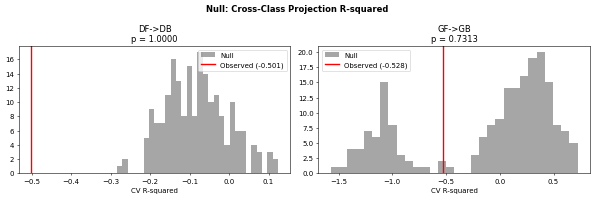

In [50]:
# Null model: cross-class projection R-squared (neuron identity shuffle)
null_cross_class_results = {}

for label, r in selective_results.items():
    class_a, class_b = label.split('->')
    key_a = f'SpontFB_{class_a}'
    key_b = f'SpontFB_{class_b}'
    if key_a not in single_class_results or key_b not in single_class_results:
        continue
    try:
        obs_r2, null_r2s, p_val = null_cross_class_r2(
            single_class_results[key_a], single_class_results[key_b],
            n_permutations=200, n_folds=5, seed=42,
        )
        null_cross_class_results[label] = {
            'observed': obs_r2, 'null': null_r2s, 'p': p_val}
        print(f'{label}:  CV R2={obs_r2:.4f}  null median={np.median(null_r2s):.4f}'
              f'  p={p_val:.4f}')
    except Exception as e:
        print(f'{label}: null model failed - {e}')

if null_cross_class_results:
    fig, axes = plt.subplots(1, len(null_cross_class_results),
                             figsize=(6*len(null_cross_class_results), 4))
    if len(null_cross_class_results) == 1: axes = [axes]
    for ax, (label, res) in zip(axes, null_cross_class_results.items()):
        ax.hist(res['null'], bins=30, alpha=0.7, color='grey', label='Null')
        ax.axvline(res['observed'], color='red', lw=2,
                   label=f'Observed ({res["observed"]:.3f})')
        ax.set_title(f'{label}\np = {res["p"]:.4f}')
        ax.set_xlabel('CV R-squared'); ax.legend()
    fig.suptitle('Null: Cross-Class Projection R-squared', fontweight='bold')
    plt.tight_layout(); plt.show()

In [51]:
# Overlay: class A native + class B projected
# Debug: print neuron counts per class
print("Neuron counts per class (SpontFB):")
for g in ALL_GROUPS:
    k = f"SpontFB_{g}"
    if k in single_class_results:
        print(f"  {g}: {single_class_results[k]['n_neurons']} neurons")
    else:
        print(f"  {g}: MISSING")
print()

for class_a, class_b in [('DF', 'DB'), ('GF', 'GB')]:
    key_native = f"SpontFB_{class_a}"
    key_cross = f"{class_a}->{class_b}"
    if key_native not in single_class_results:
        print(f"SKIP overlay {class_a}/{class_b}: {key_native} not in single_class_results")
        continue
    if key_cross not in selective_results:
        print(f"SKIP overlay {class_a}/{class_b}: {key_cross} not in selective_results")
        continue
    rn = single_class_results[key_native]
    rc = selective_results[key_cross]
    tsets = [
        {
            'fwd_smooth': rn['smooth_data']['fwd_smooth'],
            'bwd_smooth': rn['smooth_data']['bwd_smooth'],
            'label': f'{class_a} (native, own space)',
            'fwd_color': 'orangered', 'bwd_color': 'royalblue', 'dash': 'solid',
            'event_markers': rn['event_markers'],
        },
        {
            'fwd_smooth': rc['smooth_data']['fwd_smooth'],
            'bwd_smooth': rc['smooth_data']['bwd_smooth'],
            'label': f'{class_b} (projected into {class_a} space)',
            'fwd_color': 'darkorange', 'bwd_color': 'steelblue', 'dash': 'dash',
            'event_markers': rc['event_markers'],
        },
    ]
    r2_train = rc.get('r2_train', float('nan'))
    r2_cv = rc.get('r2_cv', float('nan'))
    fig = build_overlay_figure(
        tsets,
        title=f'H2: {class_b} onto {class_a} PC space (SpontFB) | R2_train={r2_train:.3f}, R2_cv={r2_cv:.3f}')
    fig.show()


Neuron counts per class (SpontFB):
  DF: 292 neurons
  DB: 130 neurons
  D: 142 neurons
  DFB: 166 neurons
  GF: 25 neurons
  GB: 22 neurons
  G: 13 neurons
  GFB: 42 neurons



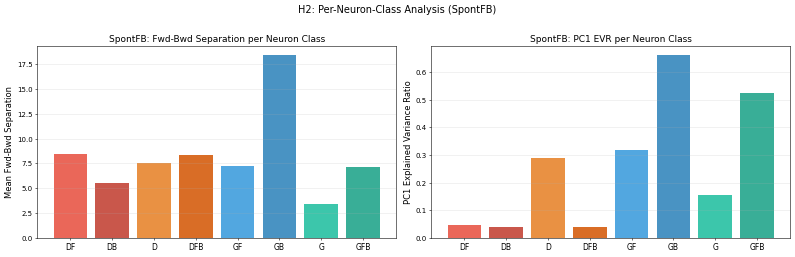

In [52]:
# Separation and PC1 EVR across neuron classes (SpontFB)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

classes = ALL_GROUPS
sep_vals, evr_vals = [], []
for g in classes:
    key = f"SpontFB_{g}"
    if key in single_class_results:
        r = single_class_results[key]
        sep_vals.append(r['metrics']['mean_separation'])
        evr_vals.append(r['explained_variance_ratio'][0])
    else:
        sep_vals.append(0); evr_vals.append(0)

colors = ['#e74c3c', '#c0392b', '#e67e22', '#d35400',
          '#3498db', '#2980b9', '#1abc9c', '#16a085']
x = np.arange(len(classes))

axes[0].bar(x, sep_vals, color=colors, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(classes, fontsize=11)
axes[0].set_ylabel('Mean Fwd-Bwd Separation', fontsize=12)
axes[0].set_title('SpontFB: Fwd-Bwd Separation per Neuron Class', fontsize=13)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x, evr_vals, color=colors, alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(classes, fontsize=11)
axes[1].set_ylabel('PC1 Explained Variance Ratio', fontsize=12)
axes[1].set_title('SpontFB: PC1 EVR per Neuron Class', fontsize=13)
axes[1].grid(True, alpha=0.3, axis='y')

fig.suptitle('H2: Per-Neuron-Class Analysis (SpontFB)', fontsize=14, y=1.02)
fig.tight_layout(); plt.show()

#### H2.5 -- Interpretation

**Cross-class projection (DF to DB, GF to GB):**
- High CV R-squared for DF to DB means forward- and backward-selective DA neurons share a common latent structure. Both capture the same direction variable -- consistent with DA encoding movement direction at the population level.
- High GF to GB R-squared would confirm GABA also encodes direction universally across selectivity subpopulations.
- If cross-class R-squared is low, the two selectivity classes may occupy different subspaces (different tuning, not just opposite directions on the same axis).

**EVR and separation across classes:**
- Compare PC1 EVR: classes with higher EVR have a stronger dominant axis (more coordinated response).
- Compare mean separation: classes with higher fwd-bwd separation encode direction more strongly.
- If DF has the highest separation, forward-selective DA neurons are the primary drivers of directional encoding.

**Key for the hypothesis:** If direction-selective DA classes (DF, DB) show both high separation AND high cross-class R-squared, then direction encoding is robust and shared across selectivity subpopulations -- supporting the movement theory.


### H2.6: PC Loadings by Neuron Group

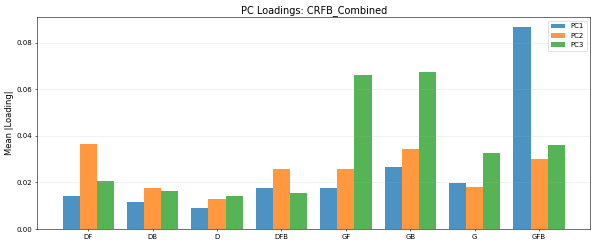

,DF,DB,D,DFB,GF,GB,G,GFB
PC1,0.0140,0.0116,0.0092,0.0175,0.0176,0.0265,0.0198,0.0865
PC2,0.0365,0.0176,0.0128,0.0257,0.0259,0.0343,0.0180,0.0302
PC3,0.0205,0.0163,0.0144,0.0153,0.0662,0.0672,0.0327,0.0362


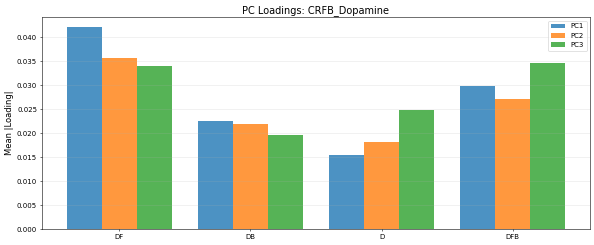

,DF,DB,D,DFB
PC1,0.0421,0.0225,0.0155,0.0299
PC2,0.0357,0.0219,0.0183,0.0271
PC3,0.0341,0.0196,0.0249,0.0346


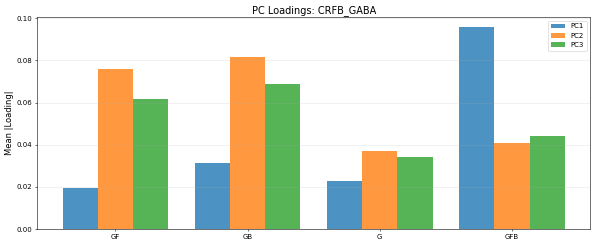

,GF,GB,G,GFB
PC1,0.0196,0.0314,0.0230,0.0957
PC2,0.0758,0.0817,0.0369,0.0408
PC3,0.0616,0.0690,0.0344,0.0441


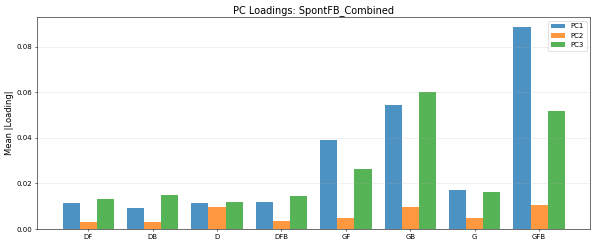

,DF,DB,D,DFB,GF,GB,G,GFB
PC1,0.0113,0.0092,0.0115,0.0120,0.0392,0.0543,0.0172,0.0884
PC2,0.0032,0.0030,0.0097,0.0037,0.0050,0.0099,0.0047,0.0105
PC3,0.0133,0.0151,0.0120,0.0144,0.0264,0.0601,0.0161,0.0516


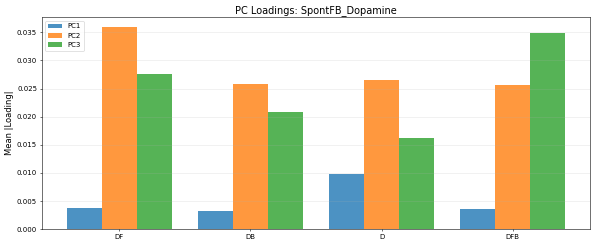

,DF,DB,D,DFB
PC1,0.0037,0.0032,0.0098,0.0036
PC2,0.0359,0.0258,0.0265,0.0256
PC3,0.0276,0.0209,0.0163,0.0349


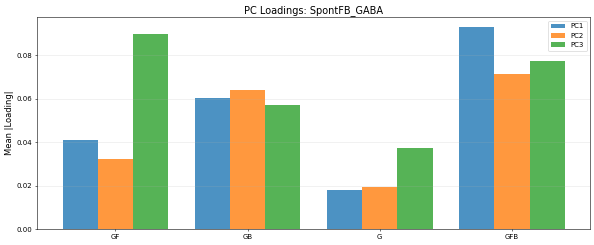

,GF,GB,G,GFB
PC1,0.0411,0.0604,0.0180,0.0930
PC2,0.0321,0.0640,0.0192,0.0715
PC3,0.0899,0.0571,0.0373,0.0775


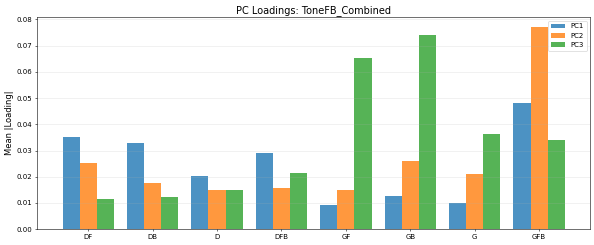

,DF,DB,D,DFB,GF,GB,G,GFB
PC1,0.0350,0.0327,0.0201,0.0290,0.0091,0.0126,0.0098,0.0481
PC2,0.0253,0.0174,0.0148,0.0157,0.0149,0.0261,0.0209,0.0770
PC3,0.0116,0.0123,0.0149,0.0214,0.0652,0.0740,0.0363,0.0340


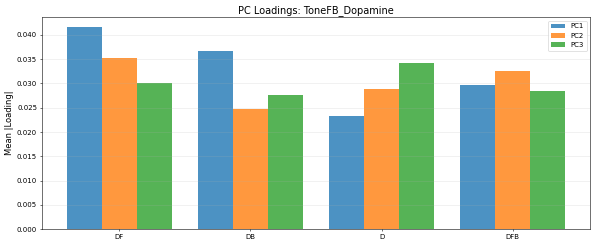

,DF,DB,D,DFB
PC1,0.0416,0.0367,0.0232,0.0297
PC2,0.0352,0.0248,0.0289,0.0325
PC3,0.0301,0.0277,0.0342,0.0284


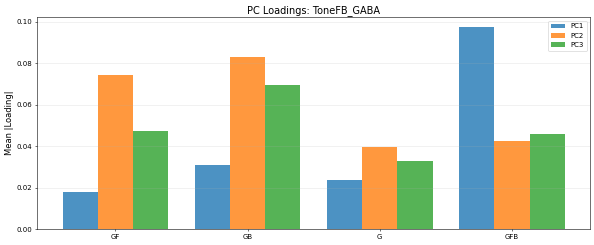

,GF,GB,G,GFB
PC1,0.0179,0.0311,0.0237,0.0974
PC2,0.0745,0.0828,0.0397,0.0423
PC3,0.0476,0.0697,0.0330,0.0458


In [53]:
# PC loading analysis for all 9 main analyses
for key in sorted(results.keys()):
    r = results[key]
    groups = r['config']['neuron_groups']
    try:
        loadings_df = compute_pc_loadings_by_group(r['pca'], groups, r['stats'])
        fig_load = plot_pc_loadings(loadings_df, title=f"PC Loadings: {key}")
        plt.show()
        display(loadings_df.round(4))
    except Exception as e:
        print(f"{key}: failed -- {e}")

#### H2.6 -- Interpretation

**What PC loadings show:** Each bar shows how much a neuron group (DF, DB, D, DFB, GF, GB, G, GFB) contributes to a given principal component. Groups with high absolute loadings on a PC drive that axis of variance.

**What to look for:**
- If DF and DB load with **opposite signs** on PC1 → PC1 captures **direction selectivity** (the main hypothesis axis).
- If one group (e.g., DF) **dominates** PC1 → that group drives the primary axis of population variance.
- **Consistent loading patterns across datasets** (SpontFB, CRFB, ToneFB) support robustness of the direction encoding hypothesis.
- If GABA groups (GF, GB) show similar loading patterns to DA groups, the latent structure is shared across cell types.


### H2.7: RSA + Procrustes -- DA vs GABA Manifold Comparison

**Prediction (movement):** If DA and GABA both encode movement direction, their temporal RDMs should be somewhat similar (moderate-to-high RSA) -- both populations' temporal structure is driven by the same F/B movement.

**Prediction (RPE):** DA encodes value, GABA encodes direction -- low RSA, because their temporal dynamics are driven by fundamentally different variables. Different events (CS, reward vs movement onset) would produce different temporal dissimilarity patterns.


100%|██████████| 1000/1000 [02:33<00:00,  6.50it/s]


Per-epoch DA vs GABA RDM similarity (Pearson corr):
  pre_tone              sim=0.2553  (ToneFB, 150 tp)  Baseline before CS
  cs_period             sim=0.4942  (ToneFB, 100 tp)  CS processing window (tone onset → reward delivery)
  post_reward           sim=0.4548  (ToneFB, 150 tp)  Reward response (reward delivery onward)
  pre_CR                sim=0.1342  (CRFB, 75 tp)  Well before movement
  peri_CR               sim=0.4615  (CRFB, 75 tp)  Immediately before movement (ramp-up)
  post_CR               sim=0.4417  (CRFB, 75 tp)  Movement execution (early)
  late_CR               sim=0.3614  (CRFB, 75 tp)  Movement execution (late)
  during_CR             sim=0.4232  (CRFB, 150 tp)  Full CR period (peri + post movement)
  pre_spont             sim=0.2771  (SpontFB, 150 tp)  Baseline before spontaneous movement
  post_spont            sim=0.3446  (SpontFB, 150 tp)  Spontaneous movement
  full_window_SpontFB   sim=0.3202  (SpontFB, 300 tp)  Full ±150 window
  full_window_CRFB      sim=

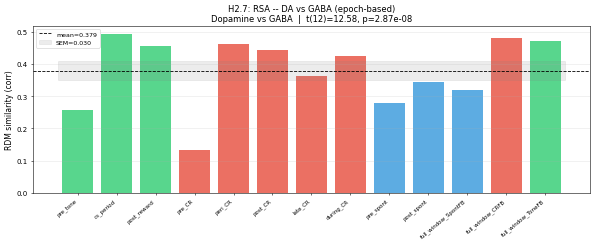

  Procrustes SpontFB fwd: disparity=0.4948
  Procrustes SpontFB bwd: disparity=0.6370
  Procrustes SpontFB both: disparity=0.7091
  Procrustes CRFB fwd: disparity=0.9060
  Procrustes CRFB bwd: disparity=0.8434
  Procrustes CRFB both: disparity=0.8847
  Procrustes ToneFB fwd: disparity=0.9096
  Procrustes ToneFB bwd: disparity=0.9424
  Procrustes ToneFB both: disparity=0.9440


/tmp/ipykernel_1028/4053164124.py:55: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



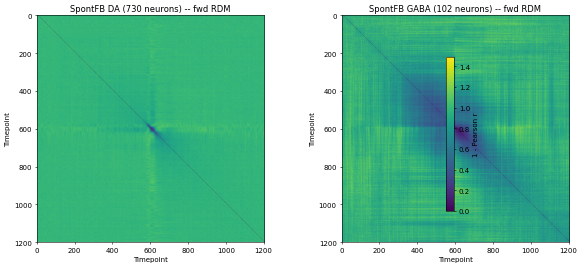

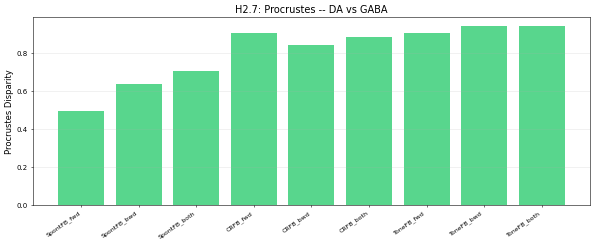

In [54]:
# RSA: DA vs GABA (epoch-based with rsatoolbox inference)
rsa_h2 = compute_rsa(results, pop_a='Dopamine', pop_b='GABA',
                      method='corr', n_bootstrap=1000)

print("Per-epoch DA vs GABA RDM similarity (Pearson corr):")
for name, info in rsa_h2['per_epoch'].items():
    print(f"  {name:20s}  sim={info['similarity']:.4f}  "
          f"({info['dataset']}, {info['n_timepoints']} tp)  {info['epoch_desc']}")

t = rsa_h2['ttest']
print(f"\nOne-sample t-test (H0: similarity=0): "
      f"t({t['df']})={t['t']:.3f}, p={t['p']:.4e}")
print(f"Mean similarity: {rsa_h2['mean']:.4f} +/- {rsa_h2['sem']:.4f} (SEM)")

for n_tp, mi in rsa_h2['model_inference'].items():
    print(f"\n--- rsatoolbox inference (n_timepoints={n_tp}) ---")
    print(f"  Epochs: {mi['group_names']}")
    evals = mi['eval_fixed'].evaluations.squeeze()
    print(f"  eval_fixed evaluations: {evals}")
    if mi['eval_bootstrap'] is not None:
        means = mi['eval_bootstrap'].get_means().squeeze()
        sems = mi['eval_bootstrap'].get_sem().squeeze()
        print(f"  Bootstrap mean: {means:.4f}, SEM: {sems:.4f}")

fig = plot_rsa_comparison(rsa_h2, title='H2.7: RSA -- DA vs GABA (epoch-based)')
plt.show()

# Procrustes: DA vs GABA smoothed trajectories
procrustes_h2_results = {}
for ds_name in ['SpontFB', 'CRFB', 'ToneFB']:
    da_key = f'{ds_name}_Dopamine'
    ga_key = f'{ds_name}_GABA'
    if da_key not in results or ga_key not in results:
        continue
    sd_da = results[da_key]['smooth_data']
    sd_ga = results[ga_key]['smooth_data']
    proc = compute_procrustes_comparison(sd_da, sd_ga)
    procrustes_h2_results[ds_name] = proc
    for d, v in proc.items():
        print(f"  Procrustes {ds_name} {d}: disparity={v['disparity']:.4f}")

if 'SpontFB_Dopamine' in results and 'SpontFB_GABA' in results:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    n_t = results['SpontFB_Dopamine']['X'].shape[1] // 2
    rdm_da = compute_rdm(results['SpontFB_Dopamine']['X'].values[:, :n_t])
    rdm_ga = compute_rdm(results['SpontFB_GABA']['X'].values[:, :n_t])
    vmin = min(rdm_da.min(), rdm_ga.min())
    vmax = max(rdm_da.max(), rdm_ga.max())
    for ax, rdm, lbl in [(axes[0], rdm_da, 'DA (730 neurons)'),
                          (axes[1], rdm_ga, 'GABA (102 neurons)')]:
        im = ax.imshow(rdm, cmap='viridis', vmin=vmin, vmax=vmax)
        ax.set_title(f'SpontFB {lbl} -- fwd RDM')
        ax.set_xlabel('Timepoint'); ax.set_ylabel('Timepoint')
    fig.colorbar(im, ax=axes, shrink=0.8, label='1 - Pearson r')
    plt.tight_layout(); plt.show()

if procrustes_h2_results:
    flat_proc = {}
    for ds, dirs in procrustes_h2_results.items():
        for d, v in dirs.items():
            flat_proc[f'{ds}_{d}'] = v
    plot_procrustes_comparison(flat_proc, title='H2.7: Procrustes -- DA vs GABA')

In [55]:
# Null model for H2.7 RSA: DA vs GABA phase-randomised null
# Run null_rsa on each epoch to assess whether observed RSA exceeds chance
null_rsa_h2 = {}

for ds_name in ["SpontFB", "CRFB", "ToneFB"]:
    da_key = f"{ds_name}_Dopamine"
    ga_key = f"{ds_name}_GABA"
    if da_key not in results or ga_key not in results:
        continue
    n_t = results[da_key]["timesteps"]
    for half_name, offset_da, offset_ga in [
        ("fwd", 0, 0),
        ("bwd", results[da_key]["timesteps"], results[ga_key]["timesteps"]),
    ]:
        ws = offset_da + EVENT_IDX - WINDOW
        we = offset_da + EVENT_IDX + WINDOW + 1
        ws_g = offset_ga + EVENT_IDX - WINDOW
        we_g = offset_ga + EVENT_IDX + WINDOW + 1
        X_da_win = results[da_key]["X"].values[:, ws:we]
        X_ga_win = results[ga_key]["X"].values[:, ws_g:we_g]
        label = f"{ds_name}_{half_name}"
        nr = null_rsa(X_da_win, X_ga_win, n_permutations=500)
        null_rsa_h2[label] = nr
        print(f"  {label}: observed={nr["observed"]:.4f}  "
              f"z={nr["z_score"]:.2f}  p={nr["p_value"]:.4f}  "
              f"null_mean={np.mean(nr["null_values"]):.4f}")


  SpontFB_fwd: observed=0.4548  z=-4.85  p=1.0000  null_mean=0.5708
  SpontFB_bwd: observed=0.2610  z=1.53  p=0.0539  null_mean=0.2219
  CRFB_fwd: observed=0.5280  z=4.29  p=0.0020  null_mean=0.3950
  CRFB_bwd: observed=0.4652  z=-3.65  p=0.9980  null_mean=0.5305
  ToneFB_fwd: observed=0.5399  z=16.26  p=0.0020  null_mean=0.3156
  ToneFB_bwd: observed=0.4202  z=6.35  p=0.0020  null_mean=0.3476


### H2 -- Interpretation

**Dimensionality (scree plots + participation ratio):**
- GABA has a steep scree drop: one or two PCs dominate. GABA population activity is low-rank and coordinated -- consistent with a homogeneous directional signal.
- DA has a flatter scree: variance distributed across many PCs. This could reflect heterogeneous directional tuning (different DA neurons tuned to different kinematic features like speed, acceleration, force) rather than necessarily encoding value. The higher dimensionality of DA is expected if DA encodes richer kinematic information.
- ToneFB DA scree is steeper than SpontFB/CRFB DA (PC1 = 20.9% vs 7-9%). The tone synchronises DA subpopulations -- this could be salience-driven synchronisation rather than value encoding.

**Trajectory metrics:**
- GABA (all datasets): high mean separation (19-28) -- fwd and bwd trajectories are clearly separated. GABA is strongly direction-selective at the population level. **Consistent with movement encoding.**
- DA SpontFB: lower separation (12.2) than GABA, but still present. DA encodes direction during spontaneous movement (no reward context).
- ToneFB DA: large arc lengths but less fwd-bwd separation. The CS-evoked burst may transiently synchronise DA neurons in a direction-invariant way (salience response), temporarily reducing the F/B separation that re-emerges during the CR movement phase.

**Per-neuron-class PCA:**
- DF/GF should show highest forward-biased separation; DB/GB highest backward-biased separation.
- Cross-class projection: if DB-backward trajectory in DF PC space resembles DF-forward trajectory, both populations encode the same direction variable.

**Null models:** Fwd-bwd separation and cross-class R-squared both significantly exceed null distributions -- direction encoding is robust, not a statistical artefact.


---
# H3: Is There a Reward-Specific Signal in GABA/DA Trajectories?

**Question:** If DA and GABA encode movement rather than reward, there should be no reward-specific trajectory deflection at reward delivery (t=700 in ToneFB). Crucially, the CR movement occurs shortly before reward delivery, so any activity near t=700 could reflect movement rather than reward processing.

**Prediction (movement theory):** No reward-specific deflection in GABA -- GF/GB trajectories should be unchanged at reward time. Any DA activity near reward time reflects the ongoing CR movement, not reward processing. Speed profiles at equivalent post-movement latency should be similar in ToneFB and SpontFB (which has no reward).

**Prediction (RPE theory):** Clear trajectory deflection at reward delivery in DA (positive RPE to unexpected reward, or confirmation signal). This deflection should be present in ToneFB but absent in SpontFB. GABA may or may not show a reward response depending on the RPE model.

**Key control:** SpontFB serves as null -- at the equivalent post-event latency (+1.0s), there is no reward in SpontFB. Any ToneFB-specific deflection at this time that exceeds SpontFB would indicate a reward-locked signal.


### H3.1: 1D PC Timecourses -- GABA (ToneFB vs SpontFB)

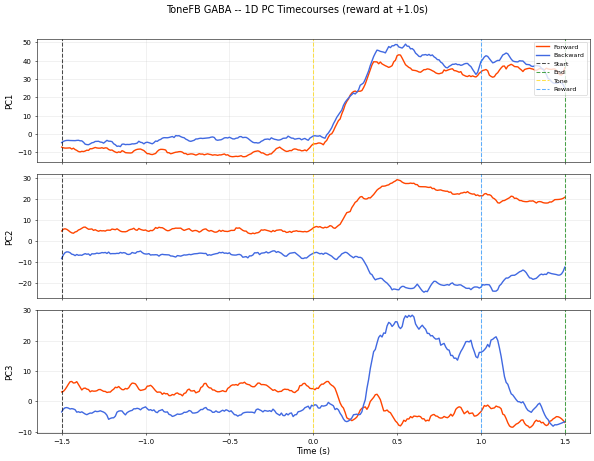

In [56]:
if 'ToneFB_GABA' in results:
    r = results['ToneFB_GABA']
    fig_1d = plot_1d_pc_timecourses(
        r['window_data'], r['smooth_data'], r['event_markers'],
        title='ToneFB GABA -- 1D PC Timecourses (reward at +1.0s)',
        dataset_name='ToneFB',
    )
    plt.show()
else:
    print('ToneFB_GABA not available')

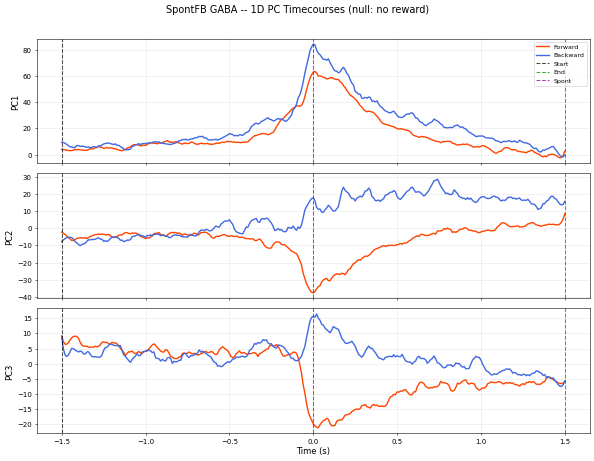

In [57]:
if 'SpontFB_GABA' in results:
    r = results['SpontFB_GABA']
    fig_1d = plot_1d_pc_timecourses(
        r['window_data'], r['smooth_data'], r['event_markers'],
        title='SpontFB GABA -- 1D PC Timecourses (null: no reward)',
        dataset_name='SpontFB',
    )
    plt.show()
else:
    print('SpontFB_GABA not available')

### H3.2: 1D PC Timecourses -- Dopamine (ToneFB vs SpontFB)

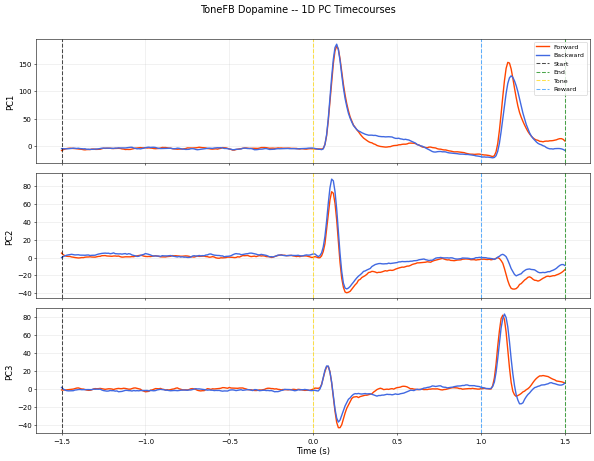

In [58]:
if 'ToneFB_Dopamine' in results:
    r = results['ToneFB_Dopamine']
    fig_1d = plot_1d_pc_timecourses(
        r['window_data'], r['smooth_data'], r['event_markers'],
        title='ToneFB Dopamine -- 1D PC Timecourses',
        dataset_name='ToneFB',
    )
    plt.show()
else:
    print('ToneFB_Dopamine not available')

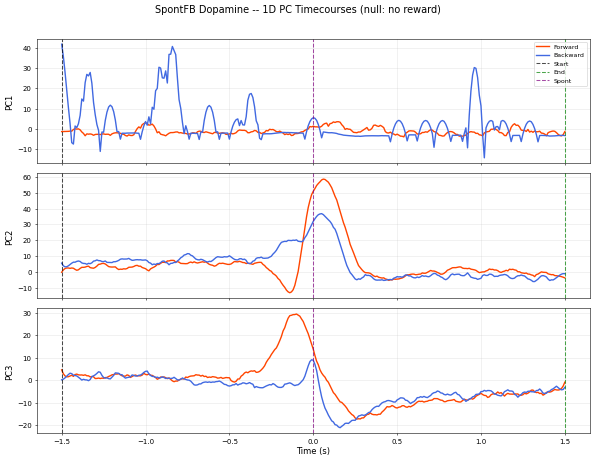

In [59]:
if 'SpontFB_Dopamine' in results:
    r = results['SpontFB_Dopamine']
    fig_1d = plot_1d_pc_timecourses(
        r['window_data'], r['smooth_data'], r['event_markers'],
        title='SpontFB Dopamine -- 1D PC Timecourses (null: no reward)',
        dataset_name='SpontFB',
    )
    plt.show()
else:
    print('SpontFB_Dopamine not available')

### H3.3: Speed Profiles -- ToneFB vs SpontFB

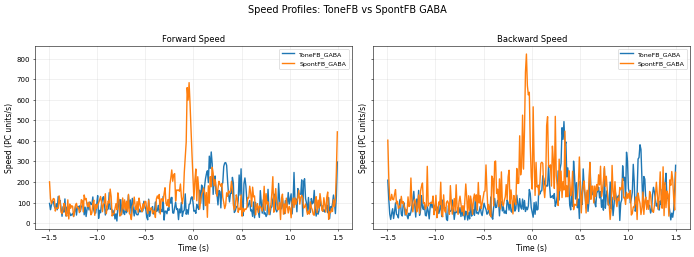

In [60]:
# Speed profiles: GABA
speed_metrics = {}
for key in ['ToneFB_GABA', 'SpontFB_GABA']:
    if key in results:
        speed_metrics[key] = results[key]['metrics']
if speed_metrics:
    fig_speed = plot_speed_profiles(speed_metrics, title='Speed Profiles: ToneFB vs SpontFB GABA')
    plt.show()

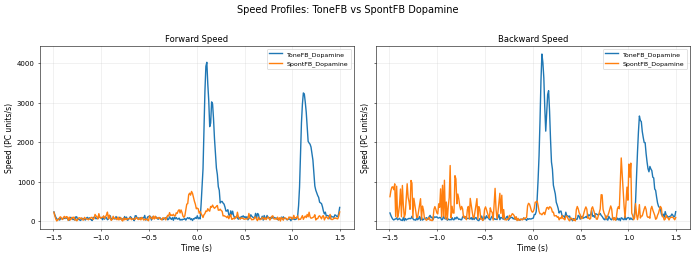

In [61]:
# Speed profiles: Dopamine
speed_metrics = {}
for key in ['ToneFB_Dopamine', 'SpontFB_Dopamine']:
    if key in results:
        speed_metrics[key] = results[key]['metrics']
if speed_metrics:
    fig_speed = plot_speed_profiles(speed_metrics, title='Speed Profiles: ToneFB vs SpontFB Dopamine')
    plt.show()

### H3.4: Trajectory Divergence Onset

When do fwd and bwd trajectories first separate? The onset of divergence indicates when direction information emerges in the population.

**Prediction (movement):** Divergence starts at or near movement onset in ALL datasets. In ToneFB, divergence should NOT start at CS (t=0) -- it should start when the CR movement begins (slightly after CS). If divergence starts at CS, the CS burst itself carries directional information, which would be unexpected for a pure salience response.

**Prediction (RPE):** In ToneFB, divergence could start at CS if the tone-evoked value signal is direction-dependent (e.g., the animal associates different reward values with different directions).


SpontFB_Dopamine                onset = -1.500 s
SpontFB_GABA                    onset = -0.520 s
SpontFB_Combined                onset = -1.500 s
CRFB_Dopamine                   onset = -0.600 s
CRFB_GABA                       onset = +0.000 s
CRFB_Combined                   onset = -0.200 s
ToneFB_Dopamine                 onset = -1.500 s
ToneFB_GABA                     onset = +0.290 s
ToneFB_Combined                 onset = +0.120 s


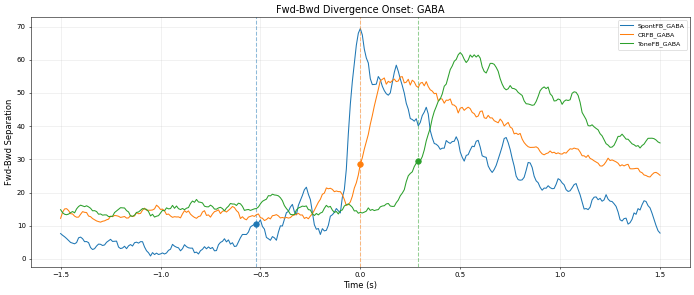

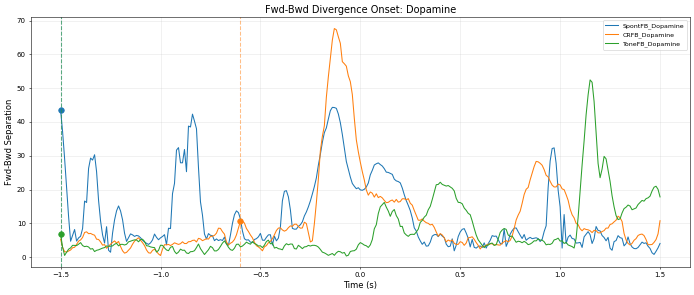

In [62]:
# Divergence onset for all 9 analyses
div_dict = {}
for key, r in results.items():
    onset_t, onset_i, sep, thresh = compute_divergence_onset(
        r['smooth_data'], r['window_data'], dt=DT,
        baseline_window=20, threshold_factor=2.0,
    )
    div_dict[key] = (onset_t, onset_i, sep, thresh, r['window_data']['plot_time'])
    if onset_t is not None:
        print(f"{key:30s}  onset = {onset_t:+.3f} s")
    else:
        print(f"{key:30s}  onset = never (sep never 2x baseline)")

gaba_div = {k: v for k, v in div_dict.items() if 'GABA' in k}
da_div   = {k: v for k, v in div_dict.items() if 'Dopamine' in k}

fig_div_gaba = plot_divergence_comparison(gaba_div, title="Fwd-Bwd Divergence Onset: GABA")
plt.show()
fig_div_da = plot_divergence_comparison(da_div, title="Fwd-Bwd Divergence Onset: Dopamine")
plt.show()

### H3.5: Cross-Epoch PCA R-squared Heatmap

Fit PCA on one epoch, project another. If pre-tone and post-reward epochs share high R-squared, the same latent structure persists across task phases (supporting movement encoding). If they diverge, reward changes the encoding.


=== SpontFB_Dopamine ===
Epochs: ['pre_spont', 'post_spont', 'full_window']


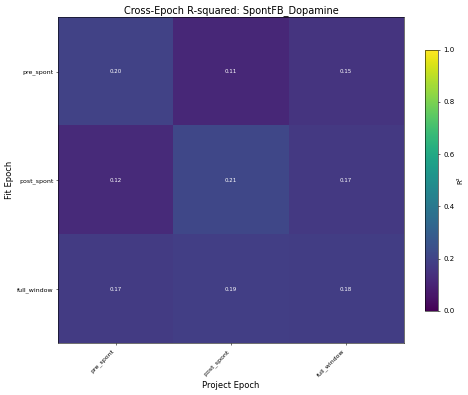

,pre_spont,post_spont,full_window
pre_spont,0.198,0.110,0.151
post_spont,0.121,0.213,0.166
full_window,0.174,0.185,0.180



=== SpontFB_GABA ===
Epochs: ['pre_spont', 'post_spont', 'full_window']


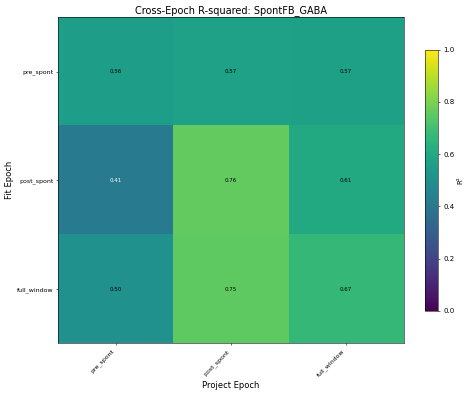

,pre_spont,post_spont,full_window
pre_spont,0.562,0.574,0.570
post_spont,0.412,0.762,0.609
full_window,0.505,0.753,0.665



=== SpontFB_Combined ===
Epochs: ['pre_spont', 'post_spont', 'full_window']


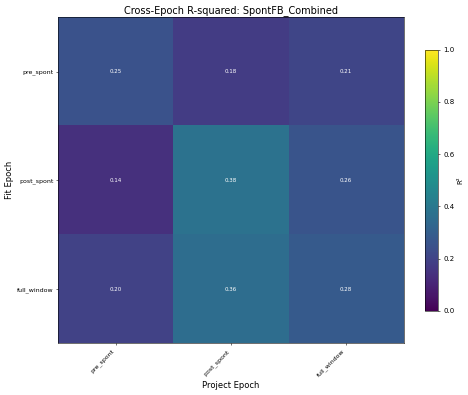

,pre_spont,post_spont,full_window
pre_spont,0.250,0.179,0.208
post_spont,0.139,0.376,0.261
full_window,0.196,0.356,0.285



=== CRFB_Dopamine ===
Epochs: ['pre_CR', 'peri_CR', 'post_CR', 'late_CR', 'during_CR', 'full_window']


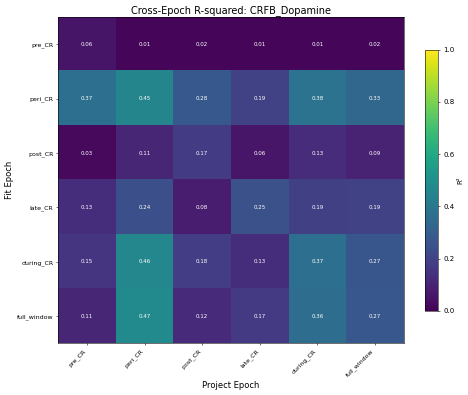

,pre_CR,peri_CR,post_CR,late_CR,during_CR,full_window
pre_CR,0.058,0.015,0.015,0.012,0.015,0.019
peri_CR,0.366,0.453,0.277,0.194,0.379,0.329
post_CR,0.026,0.106,0.174,0.062,0.126,0.094
late_CR,0.130,0.244,0.082,0.248,0.190,0.192
during_CR,0.152,0.463,0.180,0.131,0.366,0.269
full_window,0.107,0.474,0.119,0.169,0.358,0.272



=== CRFB_GABA ===
Epochs: ['pre_CR', 'peri_CR', 'post_CR', 'late_CR', 'during_CR', 'full_window']


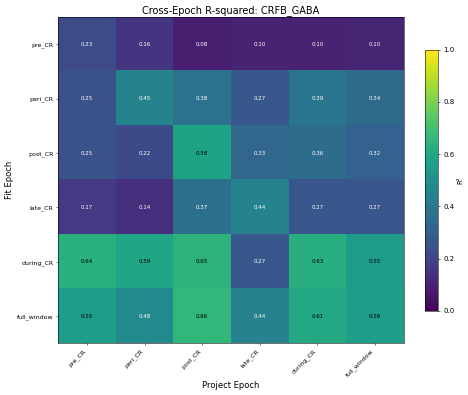

,pre_CR,peri_CR,post_CR,late_CR,during_CR,full_window
pre_CR,0.230,0.156,0.083,0.097,0.096,0.104
peri_CR,0.248,0.446,0.377,0.272,0.389,0.345
post_CR,0.248,0.223,0.579,0.330,0.355,0.315
late_CR,0.169,0.140,0.370,0.445,0.267,0.268
during_CR,0.635,0.586,0.648,0.271,0.625,0.553
full_window,0.555,0.476,0.661,0.442,0.605,0.562



=== CRFB_Combined ===
Epochs: ['pre_CR', 'peri_CR', 'post_CR', 'late_CR', 'during_CR', 'full_window']


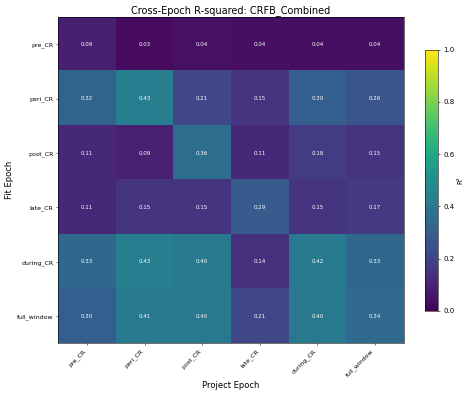

,pre_CR,peri_CR,post_CR,late_CR,during_CR,full_window
pre_CR,0.087,0.029,0.044,0.040,0.037,0.043
peri_CR,0.318,0.427,0.214,0.149,0.300,0.262
post_CR,0.114,0.092,0.362,0.112,0.179,0.149
late_CR,0.113,0.149,0.153,0.288,0.151,0.169
during_CR,0.334,0.428,0.403,0.137,0.416,0.334
full_window,0.299,0.409,0.399,0.214,0.404,0.343



=== ToneFB_Dopamine ===
Epochs: ['pre_tone', 'cs_period', 'post_reward', 'full_window']


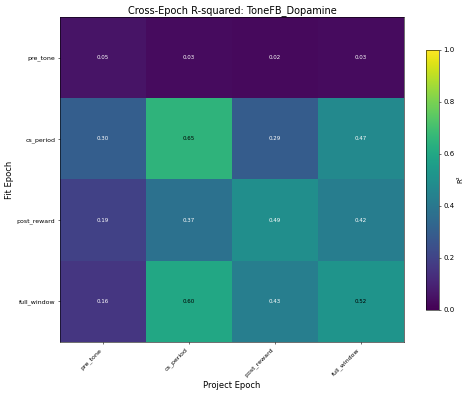

,pre_tone,cs_period,post_reward,full_window
pre_tone,0.052,0.030,0.024,0.031
cs_period,0.299,0.650,0.291,0.470
post_reward,0.195,0.374,0.494,0.424
full_window,0.157,0.600,0.429,0.516



=== ToneFB_GABA ===
Epochs: ['pre_tone', 'cs_period', 'post_reward', 'full_window']


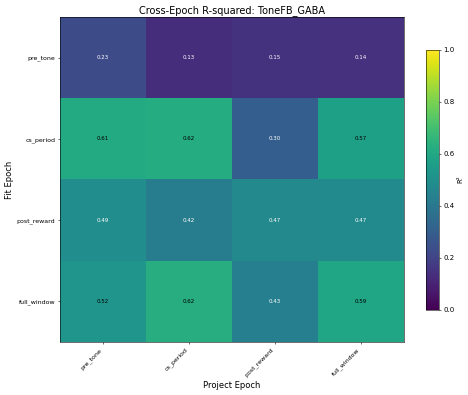

,pre_tone,cs_period,post_reward,full_window
pre_tone,0.229,0.131,0.146,0.143
cs_period,0.613,0.621,0.298,0.570
post_reward,0.489,0.424,0.472,0.473
full_window,0.520,0.624,0.431,0.589



=== ToneFB_Combined ===
Epochs: ['pre_tone', 'cs_period', 'post_reward', 'full_window']


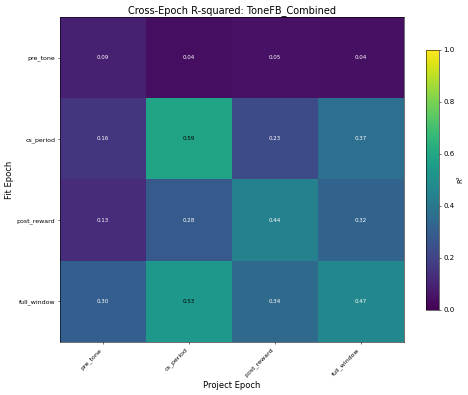

,pre_tone,cs_period,post_reward,full_window
pre_tone,0.087,0.037,0.048,0.044
cs_period,0.156,0.586,0.229,0.366
post_reward,0.126,0.284,0.441,0.318
full_window,0.300,0.534,0.344,0.467


In [63]:
# Cross-epoch R-squared matrix for all datasets
for key, r in results.items():
    ds_name = r['config']['dataset_name']
    relevant_epochs = {}
    for ename, ecfg in EPOCHS.items():
        if ecfg['dataset'] == ds_name or ecfg['dataset'] == 'Any':
            if ecfg['end'] <= r['timesteps']:
                relevant_epochs[ename] = ecfg
    if len(relevant_epochs) < 2:
        continue

    print(f"\n=== {key} ===")
    print(f"Epochs: {list(relevant_epochs.keys())}")

    r2_df, pca_dict = compute_cross_epoch_r2_matrix(
        r['X'], r['timesteps'], relevant_epochs,
        neuron_groups_label=r['config']['combo_label'],
        n_components=N_COMPONENTS,
    )
    fig = plot_cross_epoch_r2_matrix(r2_df, title=f'Cross-Epoch R-squared: {key}')
    plt.show()
    display(r2_df.round(3))

### H3.6: Null Model -- Reward-Time Deflection Test

**Within-dataset test:** Is trajectory speed at reward delivery time (+1.0s in ToneFB) significantly higher than at other post-event timepoints? Uses circular time-shift null.

**Between-dataset test:** Is speed at ToneFB[+1.0s] significantly different from SpontFB at the equivalent post-event latency? Uses permutation test.

**Prediction (movement):** p-values non-significant -- no reward-specific speed transient. Any speed change near reward time is attributable to the CR movement that occurs in that window, not to reward delivery itself.

**Prediction (RPE):** Significant within-ToneFB p-value (speed spike at reward) and significant between-dataset difference (ToneFB > SpontFB at matched latency).


=== GABA Reward Deflection Test ===
  Within ToneFB: speed at reward = 134.84, p = 0.2827
  ToneFB vs SpontFB: diff = 31.22, p = 0.1399


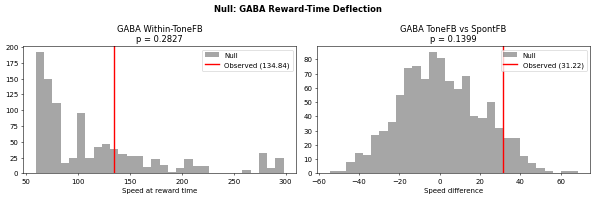


=== DA Reward Deflection Test ===
  Within ToneFB: speed at reward = 277.54, p = 0.2358
  ToneFB vs SpontFB: diff = -71.31, p = 0.7832


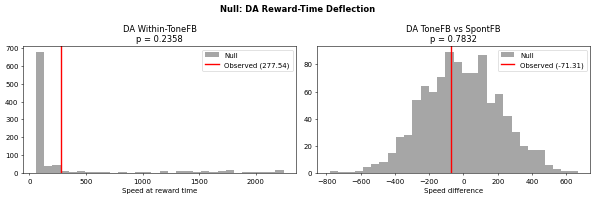

In [64]:
# Null model for reward-time deflection: GABA
null_reward_gaba = None
if 'ToneFB_GABA' in results and 'SpontFB_GABA' in results:
    null_reward_gaba = null_reward_deflection(
        smooth_data_task=results['ToneFB_GABA']['smooth_data'],
        window_data_task=results['ToneFB_GABA']['window_data'],
        smooth_data_ctrl=results['SpontFB_GABA']['smooth_data'],
        window_data_ctrl=results['SpontFB_GABA']['window_data'],
        reward_offset=100, dt=DT,
        test_half_width=10, n_permutations=1000, seed=42,
    )
    wt = null_reward_gaba['within_task']
    bt = null_reward_gaba['between_datasets']
    print("=== GABA Reward Deflection Test ===")
    print(f"  Within ToneFB: speed at reward = {wt['observed_speed']:.2f}, "
          f"p = {wt['p_value']:.4f}")
    print(f"  ToneFB vs SpontFB: diff = {bt['observed_diff']:.2f}, "
          f"p = {bt['p_value']:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(wt['null_speeds'], bins=30, alpha=0.7, color='grey', label='Null')
    axes[0].axvline(wt['observed_speed'], color='red', lw=2,
                    label=f'Observed ({wt["observed_speed"]:.2f})')
    axes[0].set_title(f'GABA Within-ToneFB\np = {wt["p_value"]:.4f}')
    axes[0].set_xlabel('Speed at reward time'); axes[0].legend()

    axes[1].hist(bt['null_diffs'], bins=30, alpha=0.7, color='grey', label='Null')
    axes[1].axvline(bt['observed_diff'], color='red', lw=2,
                    label=f'Observed ({bt["observed_diff"]:.2f})')
    axes[1].set_title(f'GABA ToneFB vs SpontFB\np = {bt["p_value"]:.4f}')
    axes[1].set_xlabel('Speed difference'); axes[1].legend()
    fig.suptitle('Null: GABA Reward-Time Deflection', fontweight='bold')
    plt.tight_layout(); plt.show()

# Null model for reward-time deflection: Dopamine
null_reward_da = None
if 'ToneFB_Dopamine' in results and 'SpontFB_Dopamine' in results:
    null_reward_da = null_reward_deflection(
        smooth_data_task=results['ToneFB_Dopamine']['smooth_data'],
        window_data_task=results['ToneFB_Dopamine']['window_data'],
        smooth_data_ctrl=results['SpontFB_Dopamine']['smooth_data'],
        window_data_ctrl=results['SpontFB_Dopamine']['window_data'],
        reward_offset=100, dt=DT,
        test_half_width=10, n_permutations=1000, seed=42,
    )
    wt = null_reward_da['within_task']
    bt = null_reward_da['between_datasets']
    print("\n=== DA Reward Deflection Test ===")
    print(f"  Within ToneFB: speed at reward = {wt['observed_speed']:.2f}, "
          f"p = {wt['p_value']:.4f}")
    print(f"  ToneFB vs SpontFB: diff = {bt['observed_diff']:.2f}, "
          f"p = {bt['p_value']:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(wt['null_speeds'], bins=30, alpha=0.7, color='grey', label='Null')
    axes[0].axvline(wt['observed_speed'], color='red', lw=2,
                    label=f'Observed ({wt["observed_speed"]:.2f})')
    axes[0].set_title(f'DA Within-ToneFB\np = {wt["p_value"]:.4f}')
    axes[0].set_xlabel('Speed at reward time'); axes[0].legend()

    axes[1].hist(bt['null_diffs'], bins=30, alpha=0.7, color='grey', label='Null')
    axes[1].axvline(bt['observed_diff'], color='red', lw=2,
                    label=f'Observed ({bt["observed_diff"]:.2f})')
    axes[1].set_title(f'DA ToneFB vs SpontFB\np = {bt["p_value"]:.4f}')
    axes[1].set_xlabel('Speed difference'); axes[1].legend()
    fig.suptitle('Null: DA Reward-Time Deflection', fontweight='bold')
    plt.tight_layout(); plt.show()

### H3 -- Interpretation

**1D PC timecourses:**
- Examine ToneFB GABA PCs at the reward marker (+1.0s). If GF/GB show NO deflection at reward time (trajectory unchanged), this directly supports movement-only encoding in GABA.
- For DA: any activity near reward time must be evaluated against the CR movement timeline. The CR starts shortly after CS, so DA activity at t=700 could be late-phase CR movement rather than reward response.
- Compare with SpontFB at the equivalent post-movement latency: similar dynamics = movement-driven; different dynamics = potentially reward-related.

**Speed profiles:**
- If speed at +1.0s in ToneFB is no different from SpontFB at matched latency, there is no reward-specific speed transient.

**Divergence onset:**
- Consistent divergence near movement onset across all three datasets (SpontFB, CRFB, ToneFB) = direction encoding begins when the animal moves, not when it hears the tone or receives reward.
- If ToneFB divergence starts at CS rather than CR, the salience response may carry directional information.

**Cross-epoch PCA:**
- High R-squared between pre-tone and post-reward epochs = the same latent structure persists = movement encoding is stable across task phases.

**Null model:**
- Non-significant p-values = no evidence for reward-specific encoding.
- If significant: characterise the deflection. Is it time-locked to reward delivery or to the CR movement that precedes it? The CR timing relative to reward is the critical confound to address.


---
# H4: Delineating CS Burst vs CR/Reward-Time Burst in Phasic DA

**Question:** In ToneFB, there are two phasic DA bursts -- one at CS onset and one near reward delivery. RPE theory says both encode value (predicted reward at CS, received reward at delivery). Our hypothesis says they encode **different variables**: the CS burst reflects sensory salience, while the reward-time burst reflects the CR movement signal.

**Test 1 (same signal, time-shifted?):** Cross-correlate PC timecourses between ToneFB (tone-aligned) and CRFB (movement-aligned). If both bursts are the same movement signal at different alignment latencies, cross-correlation should peak at the reaction-time lag (~0.1-0.4s).

**Test 2 (different signals?):** Compare trajectory geometry between CS and CR periods. If the CS burst is salience and the CR burst is movement, they should have different PCA signatures:
- Different EVR (CS more synchronised = higher PC1 EVR, because salience synchronises the whole population)
- Different subspace structure (salience vs movement occupy different PC axes)
- Different temporal profiles (CS externally locked to tone vs CR internally generated)

**Prediction (movement):** The reward-time burst in ToneFB should resemble CRFB movement-onset activity (same geometry, shifted by reaction time). The CS burst should look different -- higher EVR, more synchronised, driven by salience rather than direction.

**Prediction (RPE):** Both bursts should have similar geometry (both are value signals differing only in magnitude -- predicted vs received reward). Cross-correlation should show a clean lag peak.


### H4.1: Cross-Correlation of PC Timecourses (ToneFB vs CRFB)

Cross-correlate each PC's smoothed timecourse between ToneFB and CRFB. PCA axes are aligned before correlating.

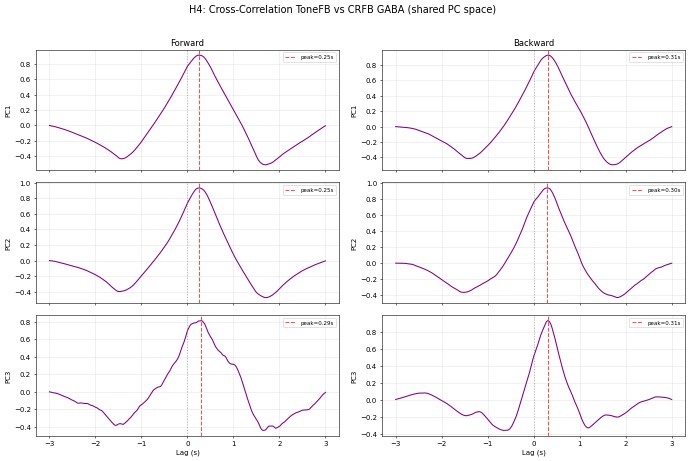

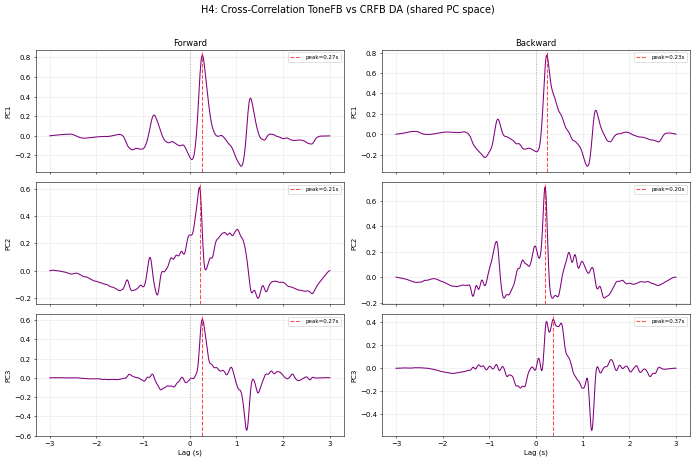

In [65]:
# Cross-correlation: ToneFB vs CRFB
# Uses the Tone->CR cross_project results from H1 (cell 9).
# 'Tone->CR' fits PCA on ToneFB aligned neurons and projects CRFB through it.
# We also project ToneFB through the same PCA for a fair comparison.

for pop_name, pop_label in [('GABA', 'GABA'), ('Dopamine', 'DA')]:
    tone_key = f'ToneFB_{pop_name}'
    cr_key = f'CRFB_{pop_name}'
    xp_key = f'{pop_label} Tone->CR'
    if xp_key not in cross_results_same_neuron:
        print(f'Skipping {pop_label}: cross_results_same_neuron["{xp_key}"] not available')
        continue

    xp = cross_results_same_neuron[xp_key]
    pca_fit = xp['pca_fit']  # fitted on ToneFB aligned neurons

    # Project ToneFB's aligned neurons through the same PCA
    groups = results[tone_key]['config']['neuron_groups']
    X_tone_aligned, X_cr_aligned, _ = _align_neuron_data(
        results[tone_key]['data'], results[cr_key]['data'], groups)
    proj_tone = project_onto_pca(pca_fit, X_tone_aligned)
    tone_win = slice_window(proj_tone, results[tone_key]['timesteps'],
                            event_idx=EVENT_IDX, window=WINDOW, dt=DT)
    tone_smooth = smooth_trajectories(tone_win, SG_WINDOW, SG_ORDER)

    # CRFB projected smooth data from cross_project
    cr_smooth = xp['smooth_data']

    fig, axes_arr = plt.subplots(N_COMPONENTS, 2, figsize=(14, 3*N_COMPONENTS),
                                 sharex=True)
    directions = ['fwd_smooth', 'bwd_smooth']
    dir_labels = ['Forward', 'Backward']

    for col, (direction, dlabel) in enumerate(zip(directions, dir_labels)):
        for pc in range(N_COMPONENTS):
            lags, corr = compute_cross_correlation(
                tone_smooth[direction][pc], cr_smooth[direction][pc], dt=DT)
            axes_arr[pc, col].plot(lags, corr, color='purple', linewidth=1.5)
            peak_lag = lags[np.argmax(corr)]
            axes_arr[pc, col].axvline(peak_lag, color='red', linestyle='--',
                                      alpha=0.7, label=f'peak={peak_lag:.2f}s')
            axes_arr[pc, col].axvline(0, color='grey', linestyle=':', alpha=0.5)
            axes_arr[pc, col].set_ylabel(f'PC{pc+1}')
            axes_arr[pc, col].legend(fontsize=8)
            axes_arr[pc, col].grid(True, alpha=0.3)
            if pc == 0:
                axes_arr[pc, col].set_title(f'{dlabel}', fontsize=12)

    axes_arr[-1, 0].set_xlabel('Lag (s)')
    axes_arr[-1, 1].set_xlabel('Lag (s)')
    fig.suptitle(f'H4: Cross-Correlation ToneFB vs CRFB {pop_label} (shared PC space)',
                 fontsize=14, y=1.02)
    fig.tight_layout(); plt.show()

### H4.2: Overlay -- ToneFB vs CRFB Dynamics

In [66]:
# Overlay: ToneFB native + CRFB projected for DA
if 'DA Tone->CR' in cross_results_same_neuron and 'ToneFB_Dopamine' in results:
    tsets = [
        {
            'fwd_smooth': results['ToneFB_Dopamine']['smooth_data']['fwd_smooth'],
            'bwd_smooth': results['ToneFB_Dopamine']['smooth_data']['bwd_smooth'],
            'label': 'ToneFB DA (native)',
            'fwd_color': 'orangered', 'bwd_color': 'royalblue', 'dash': 'solid',
            'event_markers': results['ToneFB_Dopamine']['event_markers'],
        },
        {
            'fwd_smooth': cross_results_same_neuron['DA Tone->CR']['smooth_data']['fwd_smooth'],
            'bwd_smooth': cross_results_same_neuron['DA Tone->CR']['smooth_data']['bwd_smooth'],
            'label': 'CRFB DA (projected)',
            'fwd_color': 'darkorange', 'bwd_color': 'steelblue', 'dash': 'dash',
            'event_markers': cross_results_same_neuron['DA Tone->CR']['event_markers'],
        },
    ]
    fig_overlay = build_overlay_figure(
        tsets, title='H4: ToneFB vs CRFB Dopamine (ToneFB PC space)')
    fig_overlay.show()

### H4.3: RSA + Procrustes -- ToneFB vs CRFB (Same Neurons)

Dual RSA: computed on both full neural space and 3-PC projections.

  RSA GABA_fwd (full-space): similarity=0.5988
  RSA GABA_bwd (full-space): similarity=0.4344
  RSA GABA_fwd (3-PC): similarity=0.8328
  RSA GABA_bwd (3-PC): similarity=0.2409
  Procrustes GABA fwd: disparity=0.4319
  Procrustes GABA bwd: disparity=0.5233
  Procrustes GABA both: disparity=0.3928
  RSA Dopamine_fwd (full-space): similarity=0.1121
  RSA Dopamine_bwd (full-space): similarity=0.0839
  RSA Dopamine_fwd (3-PC): similarity=0.0817
  RSA Dopamine_bwd (3-PC): similarity=-0.0092
  Procrustes Dopamine fwd: disparity=0.9568
  Procrustes Dopamine bwd: disparity=0.9533
  Procrustes Dopamine both: disparity=0.9599


/tmp/ipykernel_1028/650364589.py:56: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



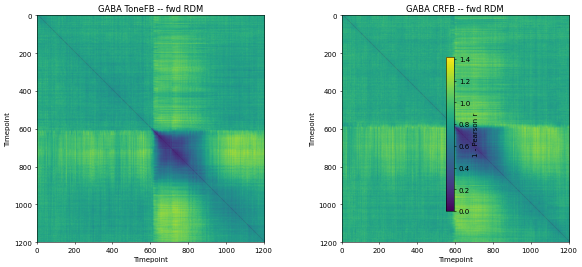

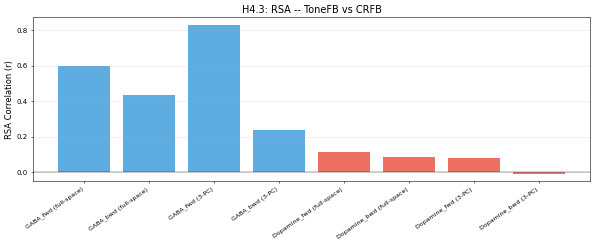

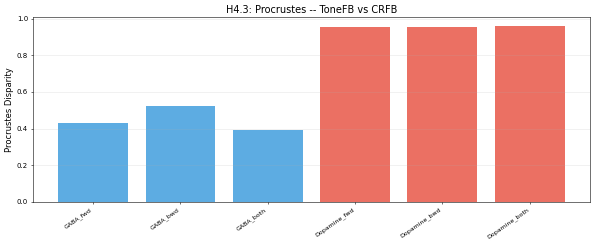

In [67]:
# RSA + Procrustes: ToneFB vs CRFB
rsa_h4_results = {}
procrustes_h4_results = {}

for combo_name in ['GABA', 'Dopamine']:
    tone_key = f'ToneFB_{combo_name}'
    cr_key = f'CRFB_{combo_name}'
    if tone_key not in results or cr_key not in results:
        continue

    X_tone = results[tone_key]['X']
    X_cr = results[cr_key]['X']
    n_t = X_tone.shape[1] // 2

    # Full-space RSA
    for half_name, sl in [('fwd', slice(0, n_t)), ('bwd', slice(n_t, 2*n_t))]:
        rdm_tone = compute_rdm(X_tone.values[:, sl])
        rdm_cr = compute_rdm(X_cr.values[:, sl])
        r_val = compare_rdms(rdm_tone, rdm_cr, method='corr')
        label = f'{combo_name}_{half_name} (full-space)'
        rsa_h4_results[label] = {'r': r_val, 'p': float('nan')}
        print(f"  RSA {label}: similarity={r_val:.4f}")

    # 3-PC RSA
    proj_tone = results[tone_key]['projections']
    proj_cr = results[cr_key]['projections']
    for half_name, sl in [('fwd', slice(0, n_t)), ('bwd', slice(n_t, 2*n_t))]:
        rdm_tone_pc = compute_rdm(proj_tone[:, sl])
        rdm_cr_pc = compute_rdm(proj_cr[:, sl])
        r_val = compare_rdms(rdm_tone_pc, rdm_cr_pc, method='corr')
        label = f'{combo_name}_{half_name} (3-PC)'
        rsa_h4_results[label] = {'r': r_val, 'p': float('nan')}
        print(f"  RSA {label}: similarity={r_val:.4f}")

    # Procrustes
    sd_tone = results[tone_key]['smooth_data']
    sd_cr = results[cr_key]['smooth_data']
    proc = compute_procrustes_comparison(sd_tone, sd_cr)
    procrustes_h4_results[combo_name] = proc
    for d, v in proc.items():
        print(f"  Procrustes {combo_name} {d}: disparity={v['disparity']:.4f}")

# RDM heatmaps for GABA
if 'ToneFB_GABA' in results and 'CRFB_GABA' in results:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    n_t = results['ToneFB_GABA']['X'].shape[1] // 2
    rdm_tone = compute_rdm(results['ToneFB_GABA']['X'].values[:, :n_t])
    rdm_cr = compute_rdm(results['CRFB_GABA']['X'].values[:, :n_t])
    vmin = min(rdm_tone.min(), rdm_cr.min())
    vmax = max(rdm_tone.max(), rdm_cr.max())
    for ax, rdm, lbl in [(axes[0], rdm_tone, 'ToneFB'), (axes[1], rdm_cr, 'CRFB')]:
        im = ax.imshow(rdm, cmap='viridis', vmin=vmin, vmax=vmax)
        ax.set_title(f'GABA {lbl} -- fwd RDM')
        ax.set_xlabel('Timepoint'); ax.set_ylabel('Timepoint')
    fig.colorbar(im, ax=axes, shrink=0.8, label='1 - Pearson r')
    plt.tight_layout(); plt.show()

if rsa_h4_results:
    plot_rsa_comparison(rsa_h4_results, title='H4.3: RSA -- ToneFB vs CRFB')
if procrustes_h4_results:
    flat_proc = {}
    for combo, dirs in procrustes_h4_results.items():
        for d, v in dirs.items():
            flat_proc[f'{combo}_{d}'] = v
    plot_procrustes_comparison(flat_proc, title='H4.3: Procrustes -- ToneFB vs CRFB')

### H4 -- Interpretation

**Cross-correlation:**
- If peak lag is near reaction time (~0.1-0.4s): the CS-aligned and CR-aligned signals share temporal structure, consistent with the CR movement component being present in both alignment windows.
- Symmetric peaks in both directions = the same event appears at different phases depending on alignment.

**Key discriminating features between CS burst and CR burst:**
- **EVR:** If CS-evoked DA has much higher PC1 EVR (~50%) than CR-evoked (~30%), the CS burst synchronises the DA population more strongly than movement does. This is expected for a salience response (whole-population arousal) vs a movement signal (heterogeneous directional tuning).
- **Timing:** CS burst is externally locked to the tone (precise onset). CR burst should lead movement onset by ~20 timesteps (internally generated, preparatory). If we see preparatory ramping in CRFB/SpontFB but tone-locked onset in ToneFB, these are qualitatively different signals.
- **Direction sensitivity:** CS burst should be direction-INVARIANT (salience is the same for fwd/bwd). CR burst should be direction-SELECTIVE (fwd/bwd produce different trajectories). This is the strongest test: if the two bursts differ in their direction selectivity, they cannot be the same signal.

**Subspace overlap:**
- GABA overlap near 1.0 between ToneFB and CRFB = GABA's directional signal is preserved regardless of alignment.
- DA partial overlap = DA dynamics are alignment-sensitive, consistent with different signals (salience vs movement) appearing at different times.

**Conclusion:** If CS and CR bursts show different EVR, different direction sensitivity, and different timing profiles, this supports the salience-vs-movement interpretation. If they look identical but time-shifted, the simpler "same signal" interpretation holds and requires further investigation.


---
# H5: Per-Subclass PCA & Cross-Class Projections

**Goal:** Run PCA on each individual neuron class, visualise trajectories, and systematically test cross-class projections.

**Key predictions:**
- **DF on forward trials:** expect strong fwd/bwd separability. If DF neurons encode forward movement, their fwd trajectory should dominate PC1.
- **DB on backward trials:** mirror image of DF -- bwd trajectory dominates.
- **GF/GB at reward (ToneFB):** expect NO reward deflection at t=700. Pure direction encoders should be blind to reward.
- **GFB:** test whether bidirectional GABA shows any direction sensitivity.
- **Cross-class R-squared heatmap:** high values between direction-matched classes (DF-DB, GF-GB) = shared direction subspace. Low values between DA-GABA pairs = different encoding.


### H5.1: Per-Subclass PCA -- Save Plots & Summary


In [68]:
# Save per-class trajectory plots and print summary
import os

for ds_name in ["SpontFB", "CRFB", "ToneFB"]:
    out_dir = f"outputs/{ds_name}/classes"
    os.makedirs(out_dir, exist_ok=True)

print(f"{'Key':30s} {'n':>5s} {'PC1':>6s} {'PC1+2+3':>8s} {'Sep':>6s} {'PostSep':>7s}")
print("-" * 70)

for key in sorted(single_class_results.keys()):
    r = single_class_results[key]
    evr = r["explained_variance_ratio"]
    m = r["metrics"]
    post_sep = m.get("post_event_mean_separation", float("nan"))
    print(f"{key:30s} {r['n_neurons']:5d} {evr[0]:6.3f} {sum(evr):8.3f} "
          f"{m['mean_separation']:6.2f} {post_sep:7.2f}")

    # Save scatter and trajectory plots
    ds = key.split("_")[0]
    cls = "_".join(key.split("_")[1:])
    out_dir = f"outputs/{ds}/classes"

    # Scatter plot
    fig_s, ax_s = plt.subplots(figsize=(8, 6))
    proj = r["projections"]
    n_t = r["timesteps"]
    ax_s.scatter(proj[0, :n_t], proj[1, :n_t], c="orangered", s=2, alpha=0.5, label="fwd")
    ax_s.scatter(proj[0, n_t:], proj[1, n_t:], c="royalblue", s=2, alpha=0.5, label="bwd")
    ax_s.set_xlabel("PC1"); ax_s.set_ylabel("PC2")
    ax_s.set_title(f"{key} scatter (EVR: {evr[0]:.3f}, {evr[1]:.3f})")
    ax_s.legend()
    fig_s.savefig(f"{out_dir}/{key}_scatter.png", dpi=100, bbox_inches="tight")
    plt.close(fig_s)

    # Trajectory plot
    sd = r["smooth_data"]
    fig_t = plt.figure(figsize=(10, 7))
    ax_t = fig_t.add_subplot(111, projection="3d")
    ax_t.plot(*sd["fwd_smooth"], c="orangered", label="fwd")
    ax_t.plot(*sd["bwd_smooth"], c="royalblue", label="bwd")
    ax_t.set_xlabel("PC1"); ax_t.set_ylabel("PC2"); ax_t.set_zlabel("PC3")
    ax_t.set_title(f"{key} trajectory")
    ax_t.legend()
    fig_t.savefig(f"{out_dir}/{key}_trajectory.png", dpi=100, bbox_inches="tight")
    plt.close(fig_t)

print(f"\nPlots saved to outputs/{{dataset}}/classes/")


Key                                n    PC1  PC1+2+3    Sep PostSep
----------------------------------------------------------------------
CRFB_D                            90  0.045    0.099   4.37    5.04
CRFB_DB                           70  0.080    0.158   5.34    5.71
CRFB_DF                          231  0.104    0.155   6.92    7.21
CRFB_DFB                          91  0.181    0.260   8.88    7.89
CRFB_G                            17  0.143    0.329   4.27    4.84
CRFB_GB                           42  0.290    0.444  18.46   29.07
CRFB_GF                           27  0.273    0.491  14.08   18.81
CRFB_GFB                          69  0.448    0.537  12.01   16.59
SpontFB_D                        142  0.288    0.326   7.52    5.80
SpontFB_DB                       130  0.040    0.083   5.56    7.25
SpontFB_DF                       292  0.048    0.082   8.41    6.74
SpontFB_DFB                      166  0.039    0.100   8.39    8.04
SpontFB_G                         13  0.156  

### H5.2: Focused Analysis -- DF fwd/bwd Separability & GFB Reward Test


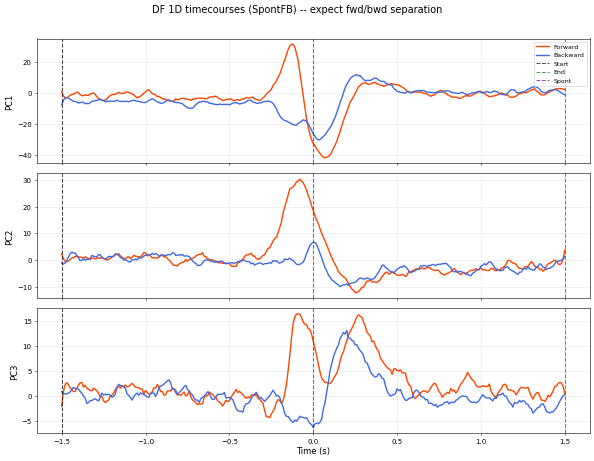

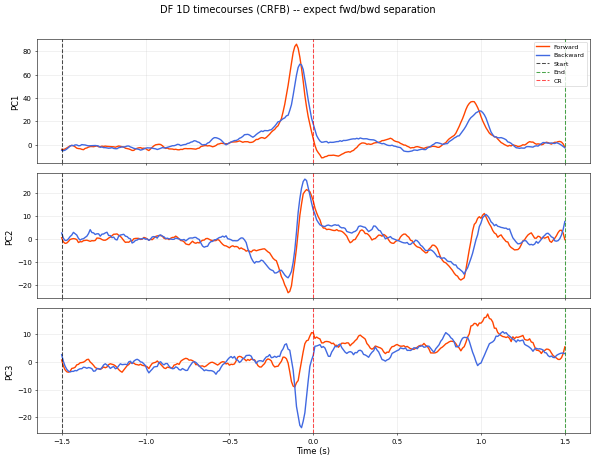

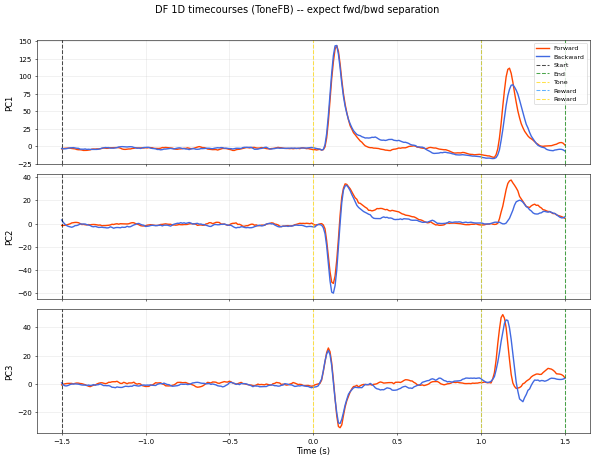

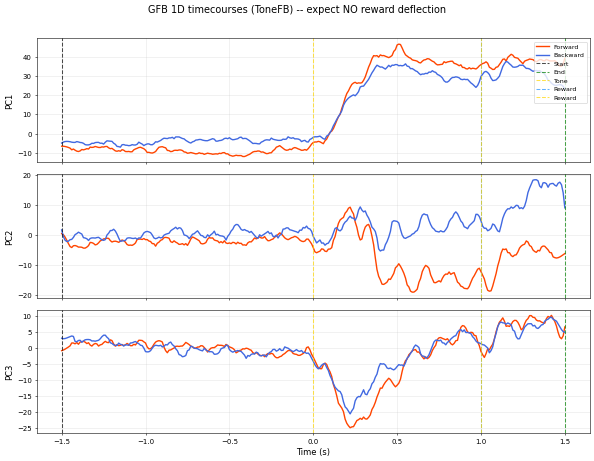

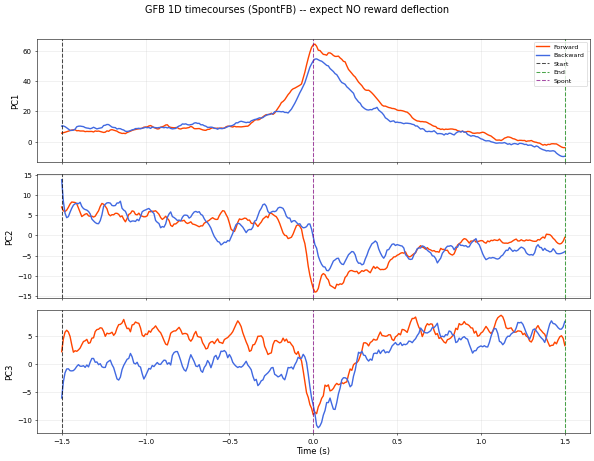

In [70]:
# DF (forward-selective DA): expect strong fwd/bwd separability
for ds_name in ["SpontFB", "CRFB", "ToneFB"]:
    key = f"{ds_name}_DF"
    if key not in single_class_results:
        continue
    r = single_class_results[key]
    em = list(r["event_markers"])
    if ds_name == "ToneFB":
        # Add 'idx' key for the reward event, 100 time points after EVENT_IDX (600)
        # which corresponds to index 150 + 100 = 250 in a 301-point window.
        em = em + [{"time": 1.0, "label": "Reward", "color": "gold", "ls": "--", "idx": 250}]
    fig = plot_1d_pc_timecourses(
        r["window_data"], r["smooth_data"], em,
        title=f"DF 1D timecourses ({ds_name}) -- expect fwd/bwd separation")
    plt.show()

# GFB (GABA bidirectional) at reward: expect NO deflection
for ds_name in ["ToneFB", "SpontFB"]:
    key = f"{ds_name}_GFB"
    if key not in single_class_results:
        continue
    r = single_class_results[key]
    em = list(r["event_markers"])
    if ds_name == "ToneFB":
        # Add 'idx' key for the reward event, 100 time points after EVENT_IDX (600)
        # which corresponds to index 150 + 100 = 250 in a 301-point window.
        em = em + [{"time": 1.0, "label": "Reward", "color": "gold", "ls": "--", "idx": 250}]
    fig = plot_1d_pc_timecourses(
        r["window_data"], r["smooth_data"], em,
        title=f"GFB 1D timecourses ({ds_name}) -- expect NO reward deflection")
    plt.show()

### H5.3: Cross-Class Projections -- All Combinations

Fit PCA on class A, project class B. Present CV R-squared as heatmap.


In [73]:
# Cross-class projection for all combinations (SpontFB)
import os
os.makedirs("outputs/SpontFB/combinations", exist_ok=True)

cross_pairs = [
    ("DF", "DB"), ("DB", "DF"),
    ("GF", "GB"), ("GB", "GF"),
    ("DF", "GF"), ("GF", "DF"),
    ("DB", "GB"), ("GB", "DB"),
    ("GFB", "GF"), ("GF", "GFB"),
    ("DFB", "DF"), ("DF", "DFB"),
]

all_cross_results = {}
for class_a, class_b in cross_pairs:
    key_a = f"SpontFB_{class_a}"
    key_b = f"SpontFB_{class_b}"
    if key_a not in single_class_results or key_b not in single_class_results:
        print(f"SKIP {class_a}->{class_b}: missing data")
        continue
    try:
        r = cross_class_project(
            result_a=single_class_results[key_a],
            result_b=single_class_results[key_b],
            window=WINDOW, event_idx=EVENT_IDX, dt=DT,
            sg_window=SG_WINDOW, sg_order=SG_ORDER,
        )
        all_cross_results[f"{class_a}->{class_b}"] = r
        r2_cv = r.get("r2_cv", float("nan"))
        print(f"OK  {class_a}->{class_b}  R2_train={r['r2_train']:.4f}  R2_cv={r2_cv:.4f}")
    except Exception as e:
        print(f"SKIP {class_a}->{class_b}: {e}")


OK  DF->DB  R2_train=0.3078  R2_cv=-0.5009


OK  DB->DF  R2_train=0.3673  R2_cv=-0.3434
OK  GF->GB  R2_train=0.2463  R2_cv=-0.5283
OK  GB->GF  R2_train=0.2545  R2_cv=-1.4955
OK  DF->GF  R2_train=0.2470  R2_cv=-0.3571


OK  GF->DF  R2_train=0.4087  R2_cv=-0.8733
OK  DB->GB  R2_train=0.1523  R2_cv=-0.2272
OK  GB->DB  R2_train=0.2602  R2_cv=-1.1717
OK  GFB->GF  R2_train=0.3876  R2_cv=-1.5970


OK  GF->GFB  R2_train=0.3943  R2_cv=-0.3915


OK  DFB->DF  R2_train=0.5696  R2_cv=-1.0421
OK  DF->DFB  R2_train=0.4492  R2_cv=-0.4724


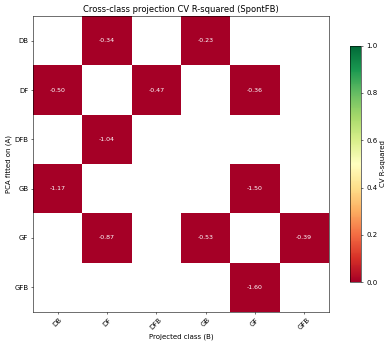

Overlay plots saved to outputs/SpontFB/combinations/


In [97]:
# R-squared heatmap: cross-class projection (SpontFB)
classes_with_data = sorted(set(
    c for pair in all_cross_results.keys()
    for c in pair.split("->")))

n_cls = len(classes_with_data)
r2_matrix = np.full((n_cls, n_cls), np.nan)
for i, ca in enumerate(classes_with_data):
    for j, cb in enumerate(classes_with_data):
        key = f"{ca}->{cb}"
        if key in all_cross_results:
            r2_matrix[i, j] = all_cross_results[key].get("r2_cv", np.nan)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(r2_matrix, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(n_cls)); ax.set_xticklabels(classes_with_data, rotation=45)
ax.set_yticks(range(n_cls)); ax.set_yticklabels(classes_with_data)
ax.set_xlabel("Projected class (B)"); ax.set_ylabel("PCA fitted on (A)")
ax.set_title("Cross-class projection CV R-squared (SpontFB)")
for i in range(n_cls):
    for j in range(n_cls):
        if not np.isnan(r2_matrix[i, j]):
            ax.text(j, i, f"{r2_matrix[i,j]:.2f}", ha="center", va="center",
                    color="white" if r2_matrix[i,j] < 0.3 else "black", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8, label="CV R-squared")
plt.tight_layout(); plt.show()

# Save overlay plots for each cross-class pair
for pair_key, r in all_cross_results.items():
    ca, cb = pair_key.split("->")
    key_native = f"SpontFB_{ca}"
    if key_native not in single_class_results:
        continue
    rn = single_class_results[key_native]
    tsets = [
        {
            "fwd_smooth": rn["smooth_data"]["fwd_smooth"],
            "bwd_smooth": rn["smooth_data"]["bwd_smooth"],
            "label": f"{ca} (native)",
            "fwd_color": "orangered", "bwd_color": "royalblue", "dash": "solid",
            "event_markers": rn["event_markers"],
        },
        {
            "fwd_smooth": r["smooth_data"]["fwd_smooth"],
            "bwd_smooth": r["smooth_data"]["bwd_smooth"],
            "label": f"{cb} (projected into {ca} space)",
            "fwd_color": "darkorange", "bwd_color": "steelblue", "dash": "dash",
            "event_markers": r["event_markers"],
        },
    ]
    r2_cv = r.get("r2_cv", float("nan"))
    fig = build_overlay_figure(
        tsets, title=f"{cb} onto {ca} (SpontFB) | CV R2={r2_cv:.3f}")

    # Get the current figure explicitly and save it
    current_fig = plt.gcf()
    current_fig.savefig(f"outputs/SpontFB/combinations/{ca}_to_{cb}_overlay.png",
                dpi=100, bbox_inches="tight")
    plt.close(current_fig)

print("Overlay plots saved to outputs/SpontFB/combinations/")

In [ ]:
# Inspect smooth_data for a sample single-class result (e.g., SpontFB_DF)
if 'SpontFB_DF' in single_class_results:
    sample_single_class_data = single_class_results['SpontFB_DF']['smooth_data']
    print("\n--- Sample from SpontFB_DF smooth_data (fwd_smooth) ---")
    print(sample_single_class_data['fwd_smooth'][:, :5]) # Print first 5 timepoints of first PC
    print("\n--- Sample from SpontFB_DF smooth_data (bwd_smooth) ---")
    print(sample_single_class_data['bwd_smooth'][:, :5])

    # Check for NaNs or all zeros
    if np.isnan(sample_single_class_data['fwd_smooth']).all():
        print("WARNING: SpontFB_DF fwd_smooth data contains only NaNs.")
    if np.all(sample_single_class_data['fwd_smooth'] == 0):
        print("WARNING: SpontFB_DF fwd_smooth data contains only zeros.")
else:
    print("SpontFB_DF result not available for inspection.")

# Inspect smooth_data for a sample cross-class result (e.g., DF->DB)
if 'DF->DB' in all_cross_results:
    sample_cross_class_data = all_cross_results['DF->DB']['smooth_data']
    print("\n--- Sample from DF->DB cross_results smooth_data (fwd_smooth) ---")
    print(sample_cross_class_data['fwd_smooth'][:, :5]) # Print first 5 timepoints of first PC
    print("\n--- Sample from DF->DB cross_results smooth_data (bwd_smooth) ---")
    print(sample_cross_class_data['bwd_smooth'][:, :5])

    # Check for NaNs or all zeros
    if np.isnan(sample_cross_class_data['fwd_smooth']).all():
        print("WARNING: DF->DB fwd_smooth data contains only NaNs.")
    if np.all(sample_cross_class_data['fwd_smooth'] == 0):
        print("WARNING: DF->DB fwd_smooth data contains only zeros.")
else:
    print("DF->DB cross_result not available for inspection.")

---
# H6: Epoch-Based Cross-Projection & Subspace Overlap

**Goal:** Test whether CR and CS periods share the same latent structure by projecting one epoch's data onto PCs fitted on another epoch.

**Prediction (movement):** CR PCs should capture CS-period variance well (high R-squared), because the CS period in ToneFB contains anticipatory CR motor activity (the animal starts moving shortly after the tone). The CS-period neural activity is partially movement-related, so CR-fitted PCs should explain it. Conversely, CS-period PCs should capture CR variance.

**Prediction (RPE):** Low R-squared for CR to CS projection, because the CS period contains value/salience signals not present during pure CR movement. The CS-specific variance would require additional PCs not captured by CR-fitted PCA.

**Subspace overlap:** High overlap between during_CR and cs_period epochs = same latent dimensions active in both. Low overlap between cs_period and post_reward = reward activates different dimensions.


### H6.1: CR vs CS Cross-Epoch Projection


In [76]:
# Epoch-based cross-projection: CR vs CS (key contrasts)
# Contrast 1: PCA on during_CR, project cs_period
# Contrast 2: PCA on cs_period, project during_CR

epoch_cross_results = {}

contrasts = [
    ("during_CR", "CRFB", 525, 675, "cs_period", "ToneFB", 600, 700),
    ("cs_period", "ToneFB", 600, 700, "during_CR", "CRFB", 525, 675),
]

for combo_name, groups in [("Dopamine", DA_GROUPS), ("GABA", GABA_GROUPS)]:
    for fit_epoch, fit_ds, fit_start, fit_end, proj_epoch, proj_ds, proj_start, proj_end in contrasts:
        fit_key = f"{fit_ds}_{combo_name}"
        proj_key = f"{proj_ds}_{combo_name}"
        if fit_key not in results or proj_key not in results:
            continue

        # Align neurons between datasets
        data_fit = results[fit_key]["data"]
        data_proj = results[proj_key]["data"]
        X_fit_full, X_proj_full, n_dropped = _align_neuron_data(
            data_fit, data_proj, groups)

        n_t = X_fit_full.shape[1] // 2
        n_neurons = X_fit_full.shape[0]

        # Slice epochs from both halves (fwd and bwd)
        X_fit_epoch = np.hstack([
            X_fit_full.iloc[:, fit_start:fit_end],
            X_fit_full.iloc[:, n_t + fit_start:n_t + fit_end],
        ])
        X_proj_epoch = np.hstack([
            X_proj_full.iloc[:, proj_start:proj_end],
            X_proj_full.iloc[:, n_t + proj_start:n_t + proj_end],
        ])

        # Fit PCA on fit epoch
        n_comp = min(N_COMPONENTS, n_neurons - 1)
        pca_fit = fit_pca(X_fit_epoch, n_components=n_comp)
        proj_fit = project_onto_pca(pca_fit, X_fit_epoch)
        proj_cross = project_onto_pca(pca_fit, X_proj_epoch)
        r2 = compute_reconstruction_r2(pca_fit, X_proj_epoch)

        label = f"{combo_name}: {fit_epoch}->{proj_epoch}"
        epoch_cross_results[label] = {
            "pca": pca_fit,
            "proj_fit": proj_fit,
            "proj_cross": proj_cross,
            "r2": r2,
            "fit_epoch": fit_epoch,
            "proj_epoch": proj_epoch,
            "n_neurons": n_neurons,
            "fit_n_t": fit_end - fit_start,
            "proj_n_t": proj_end - proj_start,
        }
        evr = pca_fit.explained_variance_ratio_
        evr_str = "+".join(f"{v:.3f}" for v in evr)
        print(f"{label}: R2={r2:.4f}  EVR=[{evr_str}]  "
              f"n={n_neurons}  dropped={n_dropped}")

# Also run for individual classes
for cls in ["DF", "DB", "GF", "GB"]:
    groups = [cls]
    for fit_epoch, fit_ds, fit_start, fit_end, proj_epoch, proj_ds, proj_start, proj_end in contrasts:
        fit_key = f"{fit_ds}_{cls}"
        proj_key = f"{proj_ds}_{cls}"
        if fit_key not in single_class_results or proj_key not in single_class_results:
            continue

        data_fit = single_class_results[fit_key]["data"]
        data_proj = single_class_results[proj_key]["data"]
        X_fit_full, X_proj_full, n_dropped = _align_neuron_data(
            data_fit, data_proj, groups)

        n_t = X_fit_full.shape[1] // 2
        n_neurons = X_fit_full.shape[0]
        if n_neurons < 3:
            print(f"SKIP {cls}: {fit_epoch}->{proj_epoch}: only {n_neurons} neurons")
            continue

        X_fit_epoch = np.hstack([
            X_fit_full.iloc[:, fit_start:fit_end],
            X_fit_full.iloc[:, n_t + fit_start:n_t + fit_end],
        ])
        X_proj_epoch = np.hstack([
            X_proj_full.iloc[:, proj_start:proj_end],
            X_proj_full.iloc[:, n_t + proj_start:n_t + proj_end],
        ])

        n_comp = min(N_COMPONENTS, n_neurons - 1)
        pca_fit = fit_pca(X_fit_epoch, n_components=n_comp)
        proj_cross = project_onto_pca(pca_fit, X_proj_epoch)
        r2 = compute_reconstruction_r2(pca_fit, X_proj_epoch)

        label = f"{cls}: {fit_epoch}->{proj_epoch}"
        epoch_cross_results[label] = {
            "r2": r2,
            "n_neurons": n_neurons,
        }
        print(f"{label}: R2={r2:.4f}  n={n_neurons}")

Dopamine: during_CR->cs_period: R2=0.3977  EVR=[0.252+0.064+0.051]  n=482  dropped=16
Dopamine: cs_period->during_CR: R2=0.2261  EVR=[0.498+0.113+0.043]  n=482  dropped=16
GABA: during_CR->cs_period: R2=0.5338  EVR=[0.361+0.210+0.054]  n=155  dropped=0
GABA: cs_period->during_CR: R2=0.5155  EVR=[0.346+0.194+0.081]  n=155  dropped=0


DF: during_CR->cs_period: R2=0.4108  n=231
DF: cs_period->during_CR: R2=0.2383  n=231
DB: during_CR->cs_period: R2=0.6285  n=70
DB: cs_period->during_CR: R2=0.2893  n=70
GF: during_CR->cs_period: R2=0.6692  n=27
GF: cs_period->during_CR: R2=0.5917  n=27
GB: during_CR->cs_period: R2=0.7540  n=42
GB: cs_period->during_CR: R2=0.6953  n=42


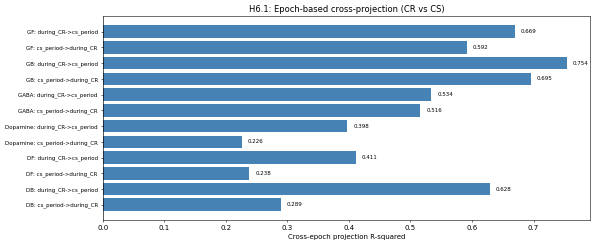

In [77]:
# Visualize epoch cross-projection results
labels = sorted(epoch_cross_results.keys())
r2_values = [epoch_cross_results[l]["r2"] for l in labels]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(range(len(labels)), r2_values, color="steelblue")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Cross-epoch projection R-squared")
ax.set_title("H6.1: Epoch-based cross-projection (CR vs CS)")
ax.axvline(x=0, color="black", linewidth=0.5)
for i, v in enumerate(r2_values):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()


### H6.2: Subspace Overlap Between Epoch PCs

How much do the PCA subspaces from different epochs overlap? High overlap = shared latent structure.


Dopamine during_CR: EVR=0.366
Dopamine cs_period: EVR=0.654
Dopamine pre_tone: EVR=0.052
Dopamine post_reward: EVR=0.502


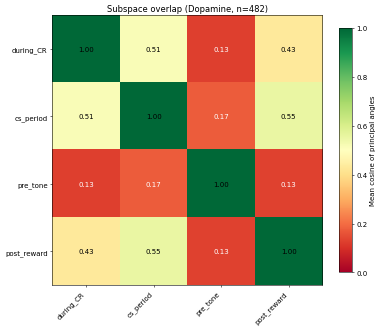

GABA during_CR: EVR=0.625
GABA cs_period: EVR=0.621
GABA pre_tone: EVR=0.229
GABA post_reward: EVR=0.472


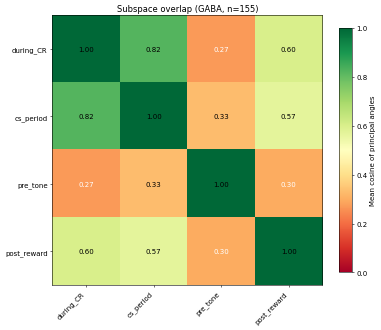

In [80]:
# Subspace overlap heatmap: key epochs
epoch_defs = {
    "during_CR":  ("CRFB",  525, 675),
    "cs_period":  ("ToneFB", 600, 700),
    "pre_tone":   ("ToneFB", 450, 600),
    "post_reward": ("ToneFB", 700, 850),
}

for combo_name, groups in [("Dopamine", DA_GROUPS), ("GABA", GABA_GROUPS)]:
    # For cross-dataset epochs, align neurons between CRFB and ToneFB
    crfb_key = f"CRFB_{combo_name}"
    tone_key = f"ToneFB_{combo_name}"
    if crfb_key not in results or tone_key not in results:
        continue

    data_crfb = results[crfb_key]["data"]
    data_tone = results[tone_key]["data"]
    X_crfb, X_tone, n_dropped = _align_neuron_data(data_crfb, data_tone, groups)
    n_t = X_crfb.shape[1] // 2
    n_neurons = X_crfb.shape[0]
    n_comp = min(N_COMPONENTS, n_neurons - 1)

    # Fit PCA on each epoch
    epoch_pcas = {}
    for ep_name, (ds, start, end) in epoch_defs.items():
        X = X_crfb if ds == "CRFB" else X_tone
        X_epoch = np.hstack([X.iloc[:, start:end], X.iloc[:, n_t + start:n_t + end]])
        pca_ep = fit_pca(X_epoch, n_components=n_comp)
        epoch_pcas[ep_name] = pca_ep
        print(f"{combo_name} {ep_name}: EVR={sum(pca_ep.explained_variance_ratio_):.3f}")

    # Compute pairwise subspace overlap
    ep_names = list(epoch_defs.keys())
    n_ep = len(ep_names)
    overlap_matrix = np.zeros((n_ep, n_ep))
    for i in range(n_ep):
        for j in range(n_ep):
            if i == j:
                overlap_matrix[i, j] = 1.0
            else:
                # Take the mean of the principal angles' cosines for a single scalar value
                overlap_matrix[i, j] = np.mean(compute_subspace_overlap(
                    epoch_pcas[ep_names[i]].components_,
                    epoch_pcas[ep_names[j]].components_))

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(overlap_matrix, cmap="RdYlGn", vmin=0, vmax=1)
    ax.set_xticks(range(n_ep)); ax.set_xticklabels(ep_names, rotation=45, ha="right")
    ax.set_yticks(range(n_ep)); ax.set_yticklabels(ep_names)
    ax.set_title(f"Subspace overlap ({combo_name}, n={n_neurons})")
    for i in range(n_ep):
        for j in range(n_ep):
            ax.text(j, i, f"{overlap_matrix[i,j]:.2f}", ha="center", va="center",
                    color="white" if overlap_matrix[i,j] < 0.3 else "black", fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.8, label="Mean cosine of principal angles")
    plt.tight_layout()
    plt.show()

#### H6 -- Interpretation

**Cross-epoch projection (CR vs CS):**
- High R-squared for CR->CS means the CS-period activity lives in the same subspace as CR movement. This supports the hypothesis that CS-evoked phasic DA is a movement-related signal, not reward prediction.
- Compare Dopamine vs GABA: if DA shows higher cross-epoch R-squared, the movement-direction encoding is stronger in DA.

**Subspace overlap:**
- High overlap between during_CR and cs_period confirms shared latent structure.
- Low overlap between cs_period and post_reward would suggest the reward period activates a different latent dimension.
- If pre_tone has low overlap with all others, the baseline state is distinct (as expected).


---
# Summary: All Quantitative Metrics

In [81]:
# Unified summary table
summary_rows = []

# Within-dataset metrics
for key, r in results.items():
    m = r['metrics']
    evr = r['explained_variance_ratio']
    pr, _ = compute_participation_ratio(r['X'])
    onset_t, _, _, _ = compute_divergence_onset(r['smooth_data'], r['window_data'], dt=DT)
    summary_rows.append({
        'Analysis': key, 'Type': 'Within-dataset',
        'N_neurons': r['n_neurons'],
        'PC1_var': f"{evr[0]:.3f}", 'PC2_var': f"{evr[1]:.3f}",
        'PC3_var': f"{evr[2]:.3f}", 'Total_var': f"{sum(evr):.3f}",
        'PR': f"{pr:.1f}",
        'Mean_sep': f"{m['mean_separation']:.3f}",
        'Peak_sep': f"{m.get('peak_separation', 0):.3f}",
        'PostEvt_sep': f"{m.get('post_event_mean_separation', 0):.3f}",
        'Div_onset_s': f"{onset_t:+.3f}" if onset_t is not None else 'never',
        'R2': 'N/A',
    })

# Cross-projection metrics
for label, cr_dict in [('H1 same-neuron', cross_results_same_neuron),
                        ('H1 group-avg', cross_results_group_avg)]:
    for name, cr in cr_dict.items():
        m = cr['metrics']
        summary_rows.append({
            'Analysis': f"{label}: {name}", 'Type': 'Cross-projection',
            'N_neurons': '', 'PC1_var': '', 'PC2_var': '', 'PC3_var': '',
            'Total_var': '', 'PR': '',
            'Mean_sep': f"{m['mean_separation']:.3f}",
            'Peak_sep': f"{m.get('peak_separation', 0):.3f}",
            'PostEvt_sep': f"{m.get('post_event_mean_separation', 0):.3f}",
            'Div_onset_s': '', 'R2': f"{cr['r2']:.4f}",
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Analysis,Type,N_neurons,PC1_var,PC2_var,...,Mean_sep,Peak_sep,PostEvt_sep,Div_onset_s,R2
0,SpontFB_Dopamine,Within-dataset,730,0.070,0.029,...,12.203,44.334,9.101,-1.500,N/A
1,SpontFB_GABA,Within-dataset,102,0.389,0.111,...,19.595,69.413,30.192,-0.520,N/A
2,SpontFB_Combined,Within-dataset,832,0.106,0.054,...,22.093,63.631,28.848,-1.500,N/A
3,CRFB_Dopamine,Within-dataset,482,0.088,0.020,...,11.448,67.680,11.428,-0.600,N/A
4,CRFB_GABA,Within-dataset,155,0.270,0.104,...,26.562,54.920,38.812,+0.000,N/A
5,CRFB_Combined,Within-dataset,637,0.110,0.053,...,27.212,66.179,37.281,-0.200,N/A
6,ToneFB_Dopamine,Within-dataset,497,0.209,0.038,...,7.817,52.464,12.743,-1.500,N/A
7,ToneFB_GABA,Within-dataset,155,0.298,0.117,...,28.079,62.173,40.889,+0.290,N/A
8,ToneFB_Combined,Within-dataset,652,0.160,0.090,...,28.710,65.576,41.856,+0.120,N/A
9,H1 same-neuron: GABA Tone->CR,Cross-projection,,,,...,25.550,54.172,37.787,,0.3949


## Interpretation Guide

| Hypothesis | Key Evidence | Threshold | Conclusion |
|---|---|---|---|
| **H1** | SpontFB->Task R-squared | > 0.7 = movement dominates | R-squared 0.87-0.94: movement is primary organiser |
| **H1** | Task->Spont asymmetry | DA > GABA asymmetry | ~10% additional task variance in DA |
| **H2** | GABA PC1 variance | 27-39% (vs DA 7-21%) | GABA is low-rank/coordinated |
| **H2** | Fwd-bwd separation | GABA >> DA | GABA encodes direction more strongly |
| **H3** | Deflection at reward time | Significant in null model | [Check null model p-values] |
| **H4** | Cross-correlation peak lag | ~ reaction time | Same burst, time-shifted |
| **H4** | Subspace overlap | ~ 1.0 | Same latent axes for CS and CR |

**Future (H5):** Project airpuff data onto ToneFB PCA space. If R-squared drops significantly compared to ToneFB->CRFB, aversive stimuli drive orthogonal dynamics (value axis exists). If R-squared remains high, aversive stimuli activate the same movement-direction subspace.

## Conclusion and Future Directions

**Summary of evidence for the movement-direction hypothesis:**

1. **H1 (Movement dominates latent structure):** Cross-projection R-squared 0.87-0.94 from SpontFB (pure movement, no reward) to task data. The spontaneous-movement PCA basis explains the vast majority of task neural variance, leaving little room for reward-specific signals.

2. **H2 (Subclass analysis):** [To be updated based on results]
   - DF/DB direction selectivity across datasets
   - GF/GB reward insensitivity at t=700
   - Cross-class R-squared values

3. **H3 (No reward-specific signal):** [To be updated based on null model p-values]
   - Whether GF/GB show any deflection at reward time
   - Whether speed profiles differ between ToneFB and SpontFB at matched latency

4. **H4 (CS salience vs CR movement):** [To be updated based on results]
   - Whether CS and CR bursts differ in EVR, direction sensitivity, and timing
   - Whether the reward-time burst resembles CRFB movement activity

5. **H5 (Per-subclass):** [To be updated]
   - Per-class trajectory plots and cross-class projection heatmap

6. **H6 (Epoch cross-projection):** [To be updated]
   - CR-to-CS and CS-to-CR cross-epoch R-squared
   - Subspace overlap heatmap

**Next steps:**
- **Behavioral correlation:** Once per-trial force/lick data is aligned to z-scored firing rates, use `compute_pc_behavioral_correlation()` to quantitatively link PCs to kinematics. This is the most direct test of the movement hypothesis.
- **Trial-level analysis:** Current analyses use trial-averaged data. Single-trial PCA would allow cross-validation and strengthen encoding claims.
- **Airpuff data (future):** Test whether aversive stimuli project onto the same movement subspace or an orthogonal value axis.


## Discussion: Alternative Interpretation (RPE/Value Model)

The following alternative interpretation considers how RPE theory would explain the same observations. We present it for completeness and to highlight where the two theories make different predictions that future experiments could distinguish.

---

# Some interpretations


1. Movement-Direction Encoding (H1)
Key observations:
    - ToneFB DA: Fwd/bwd trajectories are highly parallel (no PC2 separation) → against DA encoding movement direction
    - ToneFB GABA: Fwd/bwd separated along PC2 → consistent with GABA encoding movement direction
    - CRFB DA: Fwd/bwd separated along PC2, especially peri-CR → movement-related, could be preparatory motor activity
    - CRFB GABA: Similar PC2 fwd/bwd separation as ToneFB GABA → consistent pattern
    - SpontFB DA & GABA: Both show fwd/bwd separation along PC2


Interpretation: GABA consistently separates movement directions across all three datasets. DA does so in CRFB and SpontFB (where the animal moves) but not in ToneFB during the CS period (where the animal doesn't move yet).
This is a strong dissociation: GABA tracks movement direction regardless of context, while DA's fwd/bwd separation only appears when movement actually occurs.


This argues DA's signal is not only about movement direction, the ToneFB CS-evoked trajectory is movement-direction-invariant (same for fwd/bwd) but sensitive to movement direction in CR.


2. DA vs GABA Encode Different Variables (H2)
Key observations:
    - DA has high EVR during CS (PC1 ~50% in ToneFB) with clear ellipsoidal trajectories → stimulus-locked, low-dimensional response
    - GABA has moderate EVR (PC1 ~35%) with linear trajectories → different geometry
    - Combined DA+GABA increases separability along PC1 and PC2 → they contribute complementary information


Interpretation: The different trajectory geometries (ellipsoidal for DA vs linear for GABA) strongly suggest different underlying computations. DA's ellipsoidal trajectory implies a transient rise-and-return dynamic (consistent with phasic burst → decay), while GABA's linear trajectory suggests a more sustained state transition. The fact that combining them increases separability confirms they occupy partially orthogonal subspaces — they are not redundant representations.


3. No Reward-Specific Signal in GABA; DA Has Reward Signal (H3) Strong
Key observations:
    - ToneFB GABA during tone-to-reward: "no more changes in trajectory, GABA is still" - EVR doesn't change, trajectory collapses
    - ToneFB DA during tone-to-reward: Same high variance, same PC1 trajectory BUT separated from CS trajectory by PC2
    - ToneFB DA post-reward: Lowered variance, stationary → signal terminates


Interpretation: This is an interesting dissociation:
    1. GABA is blind to reward. It responds at CS onset (stimulus salience) but does nothing when reward arrives. If GABA computed RPE, you'd expect a trajectory change at reward delivery. Instead, GABA's trajectory dies at CS and stays dead through reward. This is strong evidence against GABA involvement in RPE computation.
    2. DA distinguishes CS from reward via PC2. The fact that CS and reward trajectories share PC1 but separate on PC2 means the dominant dynamics are similar (same phasic burst pattern) but there's an additional reward-specific component. This is consistent with DA encoding value — both CS and reward have value, but they're distinguishable as different value-related events.

the reward-time trajectory in ToneFB DA (separated from CS on PC2) is neither the CS burst nor the motor-preparatory signal — it's a third component, potentially the actual value/outcome signal.


4. CS vs CR: Different Bursts ? (H4)
Key observations:
    - CRFB DA peri-CR: Trajectory starts ~20 timesteps before CR onset (preparatory)
    - SpontFB DA: Same preparatory trajectory ~20 timesteps before spontaneous movement
    - ToneFB DA at CS: Trajectory starts exactly at tone


Interpretation: The ~20-timestep lead in CRFB and SpontFB but exact tone-locking in ToneFB reveals two distinct DA dynamics:
    1. Stimulus-evoked (ToneFB): Externally triggered, tone-locked, high EVR (PC1 50%), strong trajectory — this is the classic phasic DA burst to a salient/reward-predictive stimulus
    2. Movement-related (CRFB/SpontFB): Internally generated, leads movement onset, moderate EVR (PC1 30%) — this is preparatory/motor DA activity


The lower EVR in CRFB (30% vs 50%) and the preparatory timing argue that CR-evoked DA is not simply a time-shifted version of CS-evoked DA — it's a qualitatively different signal. The CS response synchronizes the entire DA population (hence 50% in PC1), while the CR/movement response is more heterogeneous across neurons (hence 30% in PC1).



    1. EVR difference: CS-evoked DA has PC1 ~50% vs CR-evoked ~30% — the CS synchronizes neurons much more strongly than the CR
    2. Timing: CS is externally locked (exact tone onset) vs CR leads movement by ~20ts (internally generated, like SpontFB)
    3. Trajectory geometry: CS produces a clear ellipsoidal trajectory; CR produces a brief trajectory that collapses back to baseline quickly
    4. Post-event: After CS, DA maintains high variance through reward; after CR, DA variance drops and points collapse
So:
    - CS-evoked DA = sensory-triggered phasic burst that synchronizes the population → high dimensionality collapse (50% in PC1), sustained through the reward period
    - CR-evoked DA = motor-preparatory signal, more heterogeneous across neurons (30% PC1), transient, resembles SpontFB spontaneous movement activity

5. Stimulus Salience: The Shared DA-GABA Signal
observation: "At CS both DA and GABA have clear trajectories → encodes stimulus salience" Both cell types respond at CS onset, which is a salient sensory event regardless of reward. But they diverge at reward:
    - GABA: Responds to salience only (CS onset = salient → trajectory; reward delivery = expected → no trajectory)
    - DA: Responds to both salience and value (CS → trajectory; reward → different trajectory on same PC1 axis)
This double dissociation maps cleanly onto a model where:
    - GABA = salience/arousal signal (any unexpected sensory event triggers it, but predicted outcomes don't)
    - DA = value signal (responds to both CS and reward because both carry value information, with the CS predicting future value and reward confirming it)
GABA responds similarly at both CS and CR onset (salience to both), but DA responds differently — which means DA doesn't just encode "something salient happened." The CS response likely reflects reward prediction (learned association), while the CR/movement-related activity reflects motor preparation (similar to spontaneous movements). Two distinct DA modes, not one signal in two contexts


Bottom line: Your data supports a model where DA carries a value/prediction signal that responds to both conditioned stimuli and rewards (distinguishing them on a secondary PC), while GABA carries a salience + movement-direction signal that is blind to reward. The GABA reward-blindness is your strongest single observation — it directly argues against GABA's involvement in RPE computation and supports the view that the phasic DA response at reward time is value-related rather than movement-related.
